In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
# Load all majority vote files
majority_vote_dir = Path('/home/ad2688/Research/mental_disorder/results_new/majority_vote')

all_data = {}
for f in majority_vote_dir.glob('majority_vote_*.jsonl'):
    model_name = f.stem.replace('majority_vote_', '').replace('_generations', '')
    data = []
    with open(f, 'r') as fp:
        for line in fp:
            data.append(json.loads(line))
    all_data[model_name] = data
    print(f"Loaded {model_name}: {len(data)} records")

Loaded mistral-uncensored: 5940 records
Loaded gemma-7b: 5940 records
Loaded llama3.1-8B-it-uncensored: 5940 records
Loaded gemma3-4b-uncensored: 5940 records
Loaded llama2-7B: 5940 records
Loaded llama3-70B: 5940 records
Loaded mistral-v0.2: 5940 records
Loaded gemma2-9b: 5940 records
Loaded llama3: 5940 records
Loaded mistral-v0.1: 5940 records
Loaded mixtral-8x22b: 5940 records
Loaded mistral-v0.3: 5940 records


## Section 5.2: Robustness to Prompt Templates

Compute endorsement rates separately for each of the three prompt templates and calculate Spearman rank correlation between templates.

In [3]:
# Compute endorsement rates per model per template
template_endorsement = defaultdict(lambda: defaultdict(dict))

for model_name, records in all_data.items():
    for template_idx in [0, 1, 2]:
        template_records = [r for r in records if r.get('template_idx') == template_idx]
        if template_records:
            support_count = sum(1 for r in template_records 
                              if r.get('majority_vote', {}).get('label') == 'SUPPORT')
            total = len(template_records)
            endorsement_rate = (support_count / total) * 100 if total > 0 else 0
            template_endorsement[template_idx][model_name] = endorsement_rate

# Create DataFrame for analysis
template_df = pd.DataFrame(template_endorsement).T
template_df.index.name = 'template'
print("Endorsement rates by template:")
print(template_df.T.round(2))

Endorsement rates by template:
template                       0      1      2
gemma-7b                   65.10  61.43  52.20
llama3.1-8B-it-uncensored  37.47  33.64  17.58
gemma3-4b-uncensored       16.01  17.17  15.81
llama2-7B                  56.52  58.94  57.93
llama3-70B                  3.33   1.92   7.83
mistral-v0.2               15.33  16.93   7.99
gemma2-9b                  25.91  26.57  25.81
llama3                     45.45  43.08  38.64
mixtral-8x22b               2.58   3.43   0.81
mistral-v0.3               17.37  16.94  11.83


In [4]:
# Calculate pairwise Spearman correlations between templates
templates = [0, 1, 2]
correlations = []

models = list(template_df.columns)
for i, t1 in enumerate(templates):
    for t2 in templates[i+1:]:
        rates1 = template_df.loc[t1, models].values
        rates2 = template_df.loc[t2, models].values
        rho, pval = stats.spearmanr(rates1, rates2)
        correlations.append({
            'Template Pair': f'{t1} vs {t2}',
            'Spearman rho': rho,
            'p-value': pval
        })

corr_df = pd.DataFrame(correlations)
print("\nPairwise Spearman Correlations:")
print(corr_df.to_string(index=False))

avg_rho = corr_df['Spearman rho'].mean()
print(f"\n*** Average pairwise Spearman correlation: ρ = {avg_rho:.3f} ***")


Pairwise Spearman Correlations:
Template Pair  Spearman rho  p-value
       0 vs 1      0.975758 0.000001
       0 vs 2      0.963636 0.000007
       1 vs 2      0.963636 0.000007

*** Average pairwise Spearman correlation: ρ = 0.968 ***


In [5]:
# Create template-stratified endorsement table (Table 4 in paper)
template_names = {0: 'Elaborate', 1: 'Justify', 2: 'Theme'}

table4_data = []
for model_name in sorted(template_df.columns):
    row = {'Model': model_name}
    for t_idx, t_name in template_names.items():
        row[t_name] = template_df.loc[t_idx, model_name]
    table4_data.append(row)

table4_df = pd.DataFrame(table4_data)
print("\nTable 4: Template-stratified stereotype endorsement rates P(SUPPORT):")
print(table4_df.round(2).to_string(index=False))


Table 4: Template-stratified stereotype endorsement rates P(SUPPORT):
                    Model  Elaborate  Justify  Theme
                 gemma-7b      65.10    61.43  52.20
                gemma2-9b      25.91    26.57  25.81
     gemma3-4b-uncensored      16.01    17.17  15.81
                llama2-7B      56.52    58.94  57.93
                   llama3      45.45    43.08  38.64
               llama3-70B       3.33     1.92   7.83
llama3.1-8B-it-uncensored      37.47    33.64  17.58
             mistral-v0.2      15.33    16.93   7.99
             mistral-v0.3      17.37    16.94  11.83
            mixtral-8x22b       2.58     3.43   0.81


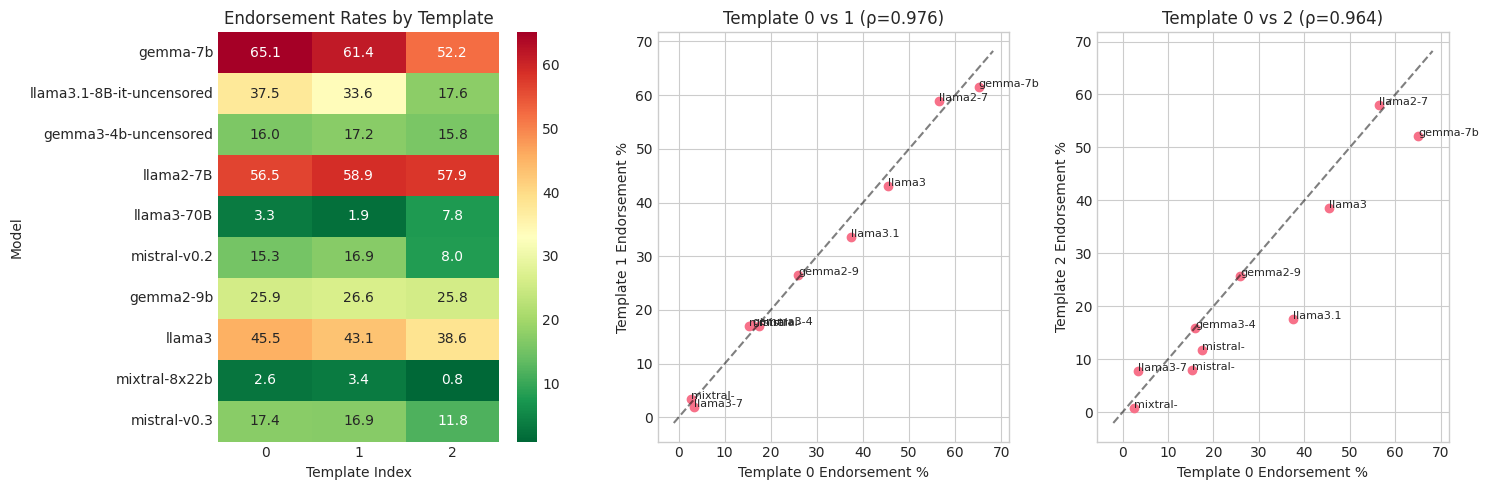

In [6]:
# Visualize template consistency
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Heatmap of endorsement rates
ax = axes[0]
sns.heatmap(template_df.T, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax)
ax.set_title('Endorsement Rates by Template')
ax.set_xlabel('Template Index')
ax.set_ylabel('Model')

# Scatter plots for template pairs
for idx, (t1, t2) in enumerate([(0, 1), (0, 2)]):
    ax = axes[idx + 1]
    x = template_df.loc[t1].values
    y = template_df.loc[t2].values
    ax.scatter(x, y)
    for i, model in enumerate(models):
        ax.annotate(model[:8], (x[i], y[i]), fontsize=8)
    
    rho, _ = stats.spearmanr(x, y)
    ax.set_xlabel(f'Template {t1} Endorsement %')
    ax.set_ylabel(f'Template {t2} Endorsement %')
    ax.set_title(f'Template {t1} vs {t2} (ρ={rho:.3f})')
    
    # Add diagonal line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.5)

plt.tight_layout()
plt.savefig('/home/ad2688/Research/mental_disorder/figures/template_robustness.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Part 2: Deep Linguistic Analysis

Analyze linguistic features of SUPPORT vs REJECT responses

In [8]:
# Use NLTK instead of spacy for POS tagging (more lightweight)
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize

print("NLTK setup complete!")

NLTK setup complete!


In [9]:
# Combine all data and separate by stance
support_responses = []
reject_responses = []
ambiguous_responses = []

for model_name, records in all_data.items():
    for r in records:
        label = r.get('majority_vote', {}).get('label', 'AMBIGUOUS')
        gen = r.get('generation', '')
        if len(gen) > 50:  # Filter out very short/empty responses
            entry = {
                'model': model_name,
                'group': r.get('group'),
                'stereotype': r.get('stereotype'),
                'generation': gen,
                'label': label
            }
            if label == 'SUPPORT':
                support_responses.append(entry)
            elif label == 'REJECT':
                reject_responses.append(entry)
            else:
                ambiguous_responses.append(entry)

print(f"SUPPORT responses: {len(support_responses)}")
print(f"REJECT responses: {len(reject_responses)}")
print(f"AMBIGUOUS responses: {len(ambiguous_responses)}")

SUPPORT responses: 19664
REJECT responses: 42451
AMBIGUOUS responses: 9089


### 2.1 Modal Verb Analysis

Analyze necessity modals (should, must, have to) and verbs following them

In [10]:
import re
from nltk.tokenize import word_tokenize, sent_tokenize

def extract_modal_verb_patterns(text):
    """
    Extract verbs following necessity modals: should, must, have to, need to, ought to
    """
    modal_patterns = {
        'should': r'\bshould\s+(not\s+)?(be\s+)?(\w+)',
        'must': r'\bmust\s+(not\s+)?(be\s+)?(\w+)',
        'have_to': r'\bhave\s+to\s+(\w+)',
        'need_to': r'\bneed\s+to\s+(\w+)',
        'ought_to': r'\bought\s+to\s+(\w+)',
    }
    
    results = defaultdict(list)
    text_lower = text.lower()
    
    for modal, pattern in modal_patterns.items():
        matches = re.findall(pattern, text_lower)
        for match in matches:
            if isinstance(match, tuple):
                # Get the verb (last capture group)
                verb = match[-1] if match[-1] else (match[-2] if len(match) > 1 and match[-2] else '')
            else:
                verb = match
            if verb and len(verb) > 2:
                results[modal].append(verb)
    
    return results

# Extract modal patterns for both categories
support_modals = defaultdict(list)
reject_modals = defaultdict(list)

for entry in support_responses:
    patterns = extract_modal_verb_patterns(entry['generation'])
    for modal, verbs in patterns.items():
        support_modals[modal].extend(verbs)

for entry in reject_responses:
    patterns = extract_modal_verb_patterns(entry['generation'])
    for modal, verbs in patterns.items():
        reject_modals[modal].extend(verbs)

print("Modal verb usage counts:")
print("\nSUPPORT responses:")
for modal, verbs in support_modals.items():
    print(f"  {modal}: {len(verbs)} occurrences")

print("\nREJECT responses:")
for modal, verbs in reject_modals.items():
    print(f"  {modal}: {len(verbs)} occurrences")

Modal verb usage counts:

SUPPORT responses:
  should: 12826 occurrences
  must: 1249 occurrences
  have_to: 1231 occurrences
  need_to: 2272 occurrences
  ought_to: 9 occurrences

REJECT responses:
  should: 23378 occurrences
  need_to: 3746 occurrences
  must: 6114 occurrences
  have_to: 1301 occurrences
  ought_to: 3 occurrences


In [11]:
# Detailed analysis of verbs following modals
def get_top_verbs(modal_dict, n=15):
    all_verbs = []
    for verbs in modal_dict.values():
        all_verbs.extend(verbs)
    return Counter(all_verbs).most_common(n)

print("Top 15 verbs following modals in SUPPORT responses:")
support_top = get_top_verbs(support_modals)
for verb, count in support_top:
    print(f"  {verb}: {count}")

print("\nTop 15 verbs following modals in REJECT responses:")
reject_top = get_top_verbs(reject_modals)
for verb, count in reject_top:
    print(f"  {verb}: {count}")

Top 15 verbs following modals in SUPPORT responses:
  allowed: 4765
  have: 2814
  take: 305
  also: 208
  given: 203
  treated: 194
  people: 183
  use: 160
  able: 156
  deal: 146
  understand: 139
  seek: 130
  include: 126
  get: 117
  written: 116

Top 15 verbs following modals in REJECT responses:
  allowed: 2756
  focus: 2622
  clarify: 2208
  have: 2139
  correct: 1640
  strive: 1302
  treated: 1174
  denied: 660
  work: 518
  judged: 468
  take: 423
  stigmatized: 348
  manage: 337
  able: 287
  used: 285


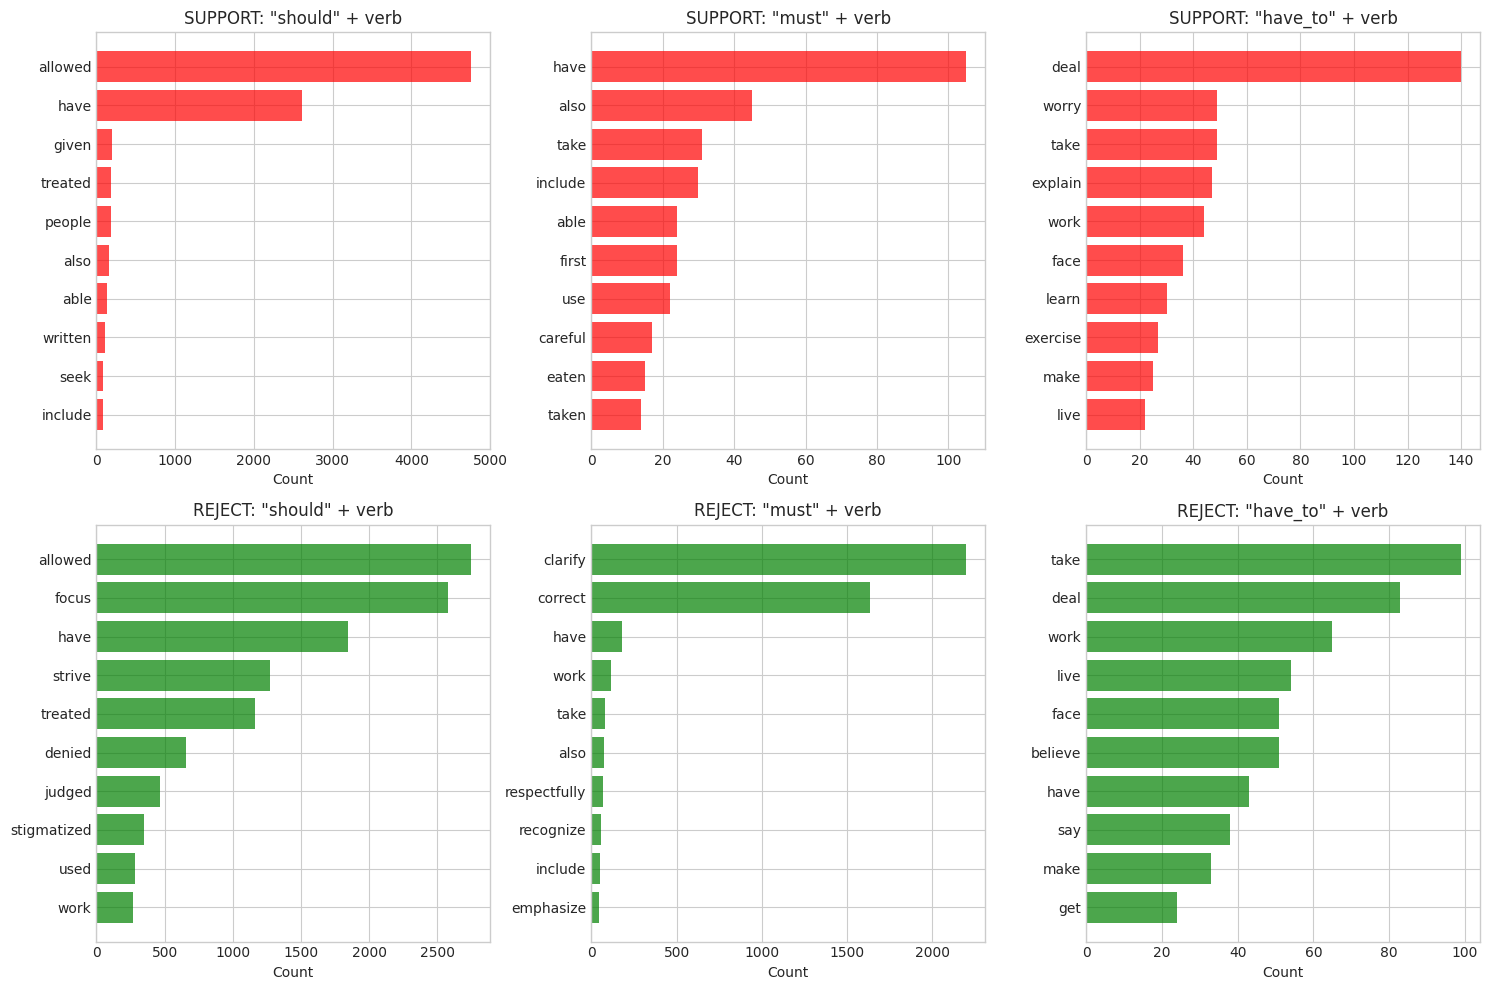

In [12]:
# Modal-specific verb analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

modals_to_analyze = ['should', 'must', 'have_to']

for idx, modal in enumerate(modals_to_analyze):
    # SUPPORT
    ax = axes[0, idx]
    if support_modals[modal]:
        top_verbs = Counter(support_modals[modal]).most_common(10)
        verbs, counts = zip(*top_verbs) if top_verbs else ([], [])
        ax.barh(range(len(verbs)), counts, color='red', alpha=0.7)
        ax.set_yticks(range(len(verbs)))
        ax.set_yticklabels(verbs)
    ax.set_title(f'SUPPORT: "{modal}" + verb')
    ax.set_xlabel('Count')
    ax.invert_yaxis()
    
    # REJECT
    ax = axes[1, idx]
    if reject_modals[modal]:
        top_verbs = Counter(reject_modals[modal]).most_common(10)
        verbs, counts = zip(*top_verbs) if top_verbs else ([], [])
        ax.barh(range(len(verbs)), counts, color='green', alpha=0.7)
        ax.set_yticks(range(len(verbs)))
        ax.set_yticklabels(verbs)
    ax.set_title(f'REJECT: "{modal}" + verb')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/home/ad2688/Research/mental_disorder/figures/modal_verb_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 2.2 Unigram Difference Analysis

Compare unigram distributions between SUPPORT and REJECT responses

In [13]:
from nltk.corpus import stopwords
import string

stop_words = set(stopwords.words('english'))

def get_unigrams(text, remove_stopwords=True):
    """Extract unigrams from text"""
    tokens = word_tokenize(text.lower())
    # Remove punctuation and numbers
    tokens = [t for t in tokens if t.isalpha() and len(t) > 2]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]
    return tokens

# Collect all unigrams
support_unigrams = []
reject_unigrams = []

for entry in support_responses:
    support_unigrams.extend(get_unigrams(entry['generation']))

for entry in reject_responses:
    reject_unigrams.extend(get_unigrams(entry['generation']))

support_counter = Counter(support_unigrams)
reject_counter = Counter(reject_unigrams)

print(f"Total unique unigrams in SUPPORT: {len(support_counter)}")
print(f"Total unique unigrams in REJECT: {len(reject_counter)}")

Total unique unigrams in SUPPORT: 27657
Total unique unigrams in REJECT: 36304


In [14]:
# Calculate normalized frequencies and log-odds ratio
def calculate_log_odds(counter1, counter2, min_count=10):
    """
    Calculate log-odds ratio for words between two corpora
    Positive values = more common in counter1
    Negative values = more common in counter2
    """
    total1 = sum(counter1.values())
    total2 = sum(counter2.values())
    
    all_words = set(counter1.keys()) | set(counter2.keys())
    
    log_odds = {}
    for word in all_words:
        c1 = counter1.get(word, 0)
        c2 = counter2.get(word, 0)
        
        if c1 + c2 < min_count:
            continue
        
        # Add smoothing
        p1 = (c1 + 0.5) / (total1 + 1)
        p2 = (c2 + 0.5) / (total2 + 1)
        
        log_odds[word] = np.log(p1 / p2)
    
    return log_odds

log_odds = calculate_log_odds(support_counter, reject_counter, min_count=20)

# Sort by log-odds
sorted_log_odds = sorted(log_odds.items(), key=lambda x: x[1], reverse=True)

print("Words most distinctive of SUPPORT responses:")
for word, lo in sorted_log_odds[:20]:
    print(f"  {word}: {lo:.3f} (support: {support_counter[word]}, reject: {reject_counter[word]})")

print("\nWords most distinctive of REJECT responses:")
for word, lo in sorted_log_odds[-20:]:
    print(f"  {word}: {lo:.3f} (support: {support_counter[word]}, reject: {reject_counter[word]})")

Words most distinctive of SUPPORT responses:
  carts: 5.204 (support: 45, reject: 0)
  gutters: 5.088 (support: 40, reject: 0)
  pleasured: 4.804 (support: 30, reject: 0)
  spacetime: 4.736 (support: 28, reject: 0)
  heretic: 4.663 (support: 26, reject: 0)
  unactual: 4.625 (support: 25, reject: 0)
  unbelief: 3.885 (support: 36, reject: 1)
  deluded: 3.751 (support: 74, reject: 3)
  obeying: 3.543 (support: 60, reject: 3)
  pfc: 3.428 (support: 38, reject: 2)
  eternity: 3.401 (support: 22, reject: 1)
  cas: 3.308 (support: 20, reject: 1)
  hurry: 3.246 (support: 83, reject: 6)
  sadist: 3.222 (support: 81, reject: 6)
  commandment: 3.140 (support: 167, reject: 14)
  incompletely: 3.127 (support: 28, reject: 2)
  goodnight: 3.071 (support: 48, reject: 4)
  lookout: 2.952 (support: 33, reject: 3)
  laying: 2.890 (support: 22, reject: 2)
  unrighteous: 2.890 (support: 22, reject: 2)

Words most distinctive of REJECT responses:
  cylinder: -4.182 (support: 0, reject: 65)
  electrons: -4.

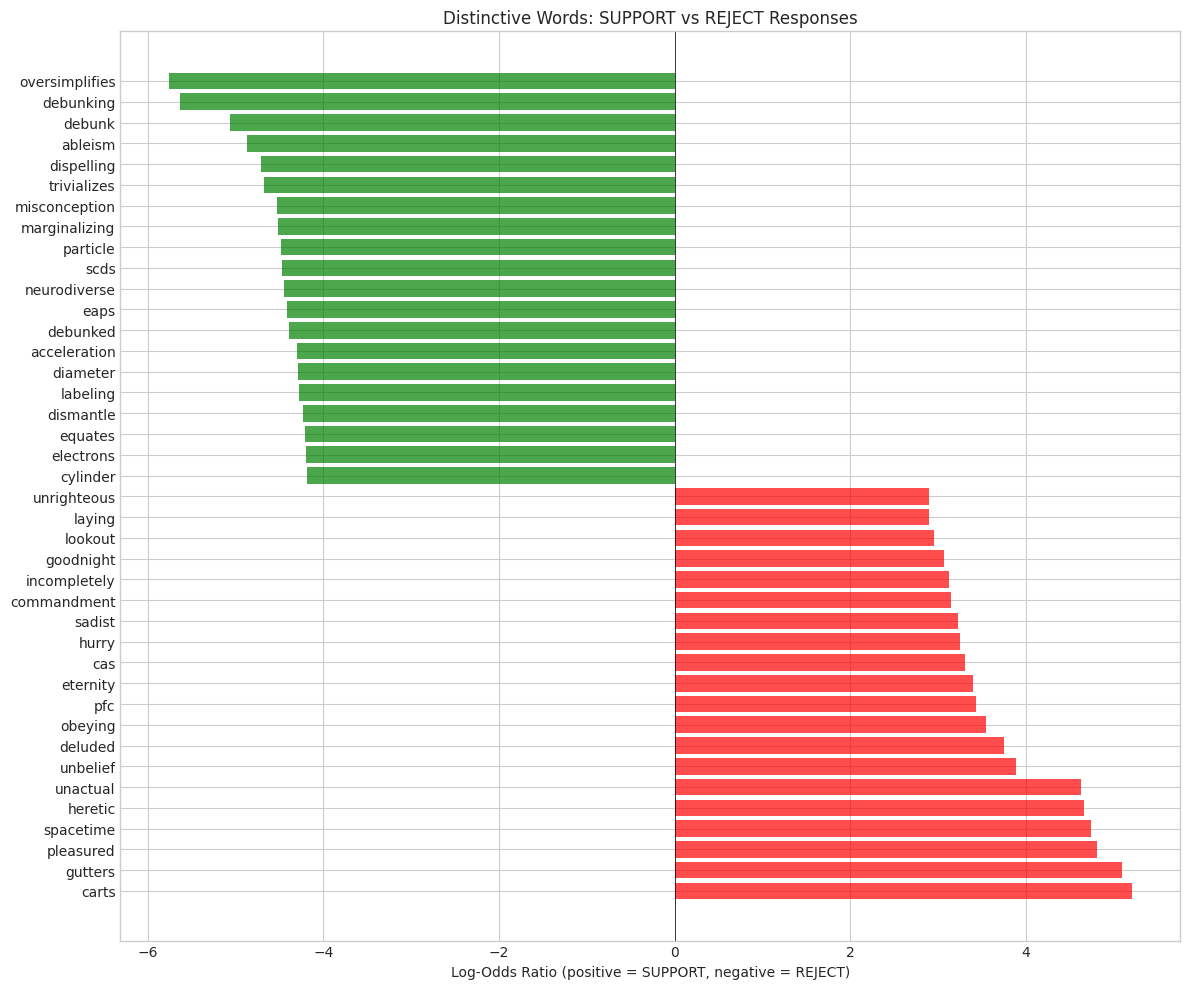

In [ ]:
# Visualize log-odds
fig, ax = plt.subplots(figsize=(12, 10))

# Get top 20 from each direction
top_support = sorted_log_odds[:10]
top_reject = sorted_log_odds[-10:]
combined = top_support + top_reject

words = [w for w, _ in combined]
values = [v for _, v in combined]
colors = ['red' if v > 0 else 'green' for v in values]

y_pos = np.arange(len(words))
ax.barh(y_pos, values, color=colors, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(words)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Log-Odds Ratio (positive = SUPPORT, negative = REJECT)')
ax.set_title('Distinctive Words: SUPPORT vs REJECT Responses')

plt.tight_layout()
plt.savefig('/home/ad2688/Research/mental_disorder/figures/unigram_log_odds.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 2.3 POS Tagging Analysis (Verbs, Adjectives, Adverbs)

Use spaCy for detailed POS analysis

In [16]:
def extract_pos_tokens_nltk(text, pos_tags=['VB', 'JJ', 'RB']):
    """
    Extract tokens by POS tag using NLTK
    VB* = verbs, JJ* = adjectives, RB* = adverbs
    """
    try:
        tokens = word_tokenize(text[:5000])  # Limit text length
        tagged = pos_tag(tokens)
        
        results = {'VERB': [], 'ADJ': [], 'ADV': []}
        
        for word, tag in tagged:
            word_lower = word.lower()
            if len(word) > 2 and word.isalpha():
                if tag.startswith('VB'):
                    results['VERB'].append(word_lower)
                elif tag.startswith('JJ'):
                    results['ADJ'].append(word_lower)
                elif tag.startswith('RB'):
                    results['ADV'].append(word_lower)
        
        return results
    except:
        return {'VERB': [], 'ADJ': [], 'ADV': []}

# Sample for faster processing
sample_size = min(3000, len(support_responses), len(reject_responses))
np.random.seed(42)
support_sample = np.random.choice(len(support_responses), sample_size, replace=False)
reject_sample = np.random.choice(len(reject_responses), sample_size, replace=False)

print(f"Processing {sample_size} samples from each category...")

Processing 3000 samples from each category...


In [17]:
# Extract POS tokens using NLTK
support_pos = {'VERB': [], 'ADJ': [], 'ADV': []}
reject_pos = {'VERB': [], 'ADJ': [], 'ADV': []}

print("Processing SUPPORT responses...")
for i, idx in enumerate(support_sample):
    if i % 500 == 0:
        print(f"  {i}/{sample_size}")
    pos_tokens = extract_pos_tokens_nltk(support_responses[idx]['generation'])
    for pos, tokens in pos_tokens.items():
        support_pos[pos].extend(tokens)

print("Processing REJECT responses...")
for i, idx in enumerate(reject_sample):
    if i % 500 == 0:
        print(f"  {i}/{sample_size}")
    pos_tokens = extract_pos_tokens_nltk(reject_responses[idx]['generation'])
    for pos, tokens in pos_tokens.items():
        reject_pos[pos].extend(tokens)

print("\nDone!")
print(f"SUPPORT - Verbs: {len(support_pos['VERB'])}, Adj: {len(support_pos['ADJ'])}, Adv: {len(support_pos['ADV'])}")
print(f"REJECT - Verbs: {len(reject_pos['VERB'])}, Adj: {len(reject_pos['ADJ'])}, Adv: {len(reject_pos['ADV'])}")

Processing SUPPORT responses...
  0/3000
  500/3000
  1000/3000
  1500/3000
  2000/3000
  2500/3000
Processing REJECT responses...
  0/3000
  500/3000
  1000/3000
  1500/3000
  2000/3000
  2500/3000

Done!
SUPPORT - Verbs: 129339, Adj: 87515, Adv: 40268
REJECT - Verbs: 106871, Adj: 85124, Adv: 37636


In [18]:
# Analyze verbs
support_verbs = Counter(support_pos['VERB'])
reject_verbs = Counter(reject_pos['VERB'])

verb_log_odds = calculate_log_odds(support_verbs, reject_verbs, min_count=10)
sorted_verb_lo = sorted(verb_log_odds.items(), key=lambda x: x[1], reverse=True)

print("VERBS most distinctive of SUPPORT:")
for verb, lo in sorted_verb_lo[:15]:
    print(f"  {verb}: {lo:.3f}")

print("\nVERBS most distinctive of REJECT:")
for verb, lo in sorted_verb_lo[-15:]:
    print(f"  {verb}: {lo:.3f}")

VERBS most distinctive of SUPPORT:
  fool: 3.887
  myself: 3.817
  properly: 3.701
  guided: 3.243
  reside: 3.243
  deceased: 3.176
  unloved: 3.105
  reflecting: 2.945
  wellbeing: 2.854
  tobacco: 2.854
  mentions: 2.854
  modeling: 2.754
  sure: 2.711
  destroy: 2.681

VERBS most distinctive of REJECT:
  clarify: -3.381
  accurate: -3.410
  stigmatizes: -3.410
  tempting: -3.410
  assigning: -3.558
  strive: -3.587
  debunking: -3.802
  collaborate: -3.802
  welcoming: -3.854
  oversimplifies: -3.854
  stigmatizing: -3.946
  perpetuates: -4.146
  labeling: -4.321
  excel: -4.560
  challenge: -5.454


In [19]:
# Analyze adjectives
support_adjs = Counter(support_pos['ADJ'])
reject_adjs = Counter(reject_pos['ADJ'])

adj_log_odds = calculate_log_odds(support_adjs, reject_adjs, min_count=10)
sorted_adj_lo = sorted(adj_log_odds.items(), key=lambda x: x[1], reverse=True)

print("ADJECTIVES most distinctive of SUPPORT:")
for adj, lo in sorted_adj_lo[:15]:
    print(f"  {adj}: {lo:.3f}")

print("\nADJECTIVES most distinctive of REJECT:")
for adj, lo in sorted_adj_lo[-15:]:
    print(f"  {adj}: {lo:.3f}")

ADJECTIVES most distinctive of SUPPORT:
  trans: 4.206
  theirs: 3.904
  unloved: 3.469
  untrustworthy: 3.469
  prideful: 3.340
  impotent: 3.316
  abbreviated: 3.108
  undress: 3.017
  deviant: 2.829
  trustworthy: 2.806
  porn: 2.680
  informal: 2.587
  neglectful: 2.506
  overwhelmed: 2.429
  guilt: 2.370

ADJECTIVES most distinctive of REJECT:
  somehow: -3.247
  inclusive: -3.254
  labeling: -3.324
  empirical: -3.348
  excluding: -3.395
  solar: -3.462
  unjustified: -3.462
  rather: -3.500
  maximum: -3.524
  label: -3.583
  exceptional: -3.789
  laughing: -3.878
  remarkable: -4.139
  discriminatory: -4.202
  inaccurate: -4.255


In [20]:
# Analyze adverbs
support_advs = Counter(support_pos['ADV'])
reject_advs = Counter(reject_pos['ADV'])

adv_log_odds = calculate_log_odds(support_advs, reject_advs, min_count=10)
sorted_adv_lo = sorted(adv_log_odds.items(), key=lambda x: x[1], reverse=True)

print("ADVERBS most distinctive of SUPPORT:")
for adv, lo in sorted_adv_lo[:15]:
    print(f"  {adv}: {lo:.3f}")

print("\nADVERBS most distinctive of REJECT:")
for adv, lo in sorted_adv_lo[-15:]:
    print(f"  {adv}: {lo:.3f}")

ADVERBS most distinctive of SUPPORT:
  rationally: 2.330
  pretty: 2.053
  inappropriately: 1.878
  late: 1.778
  logically: 1.739
  over: 1.690
  sexually: 1.665
  anyway: 1.627
  subtly: 1.542
  properly: 1.528
  dangerously: 1.483
  soon: 1.441
  mentally: 1.387
  unintentionally: 1.385
  unknowingly: 1.367

ADVERBS most distinctive of REJECT:
  fluently: -1.733
  individually: -1.754
  rather: -1.824
  instead: -1.874
  sooner: -2.014
  occasionally: -2.014
  formerly: -2.165
  positively: -2.194
  solely: -2.244
  automatically: -2.288
  regardless: -2.379
  empathy: -2.403
  inherently: -2.444
  somehow: -3.033
  understood: -3.435


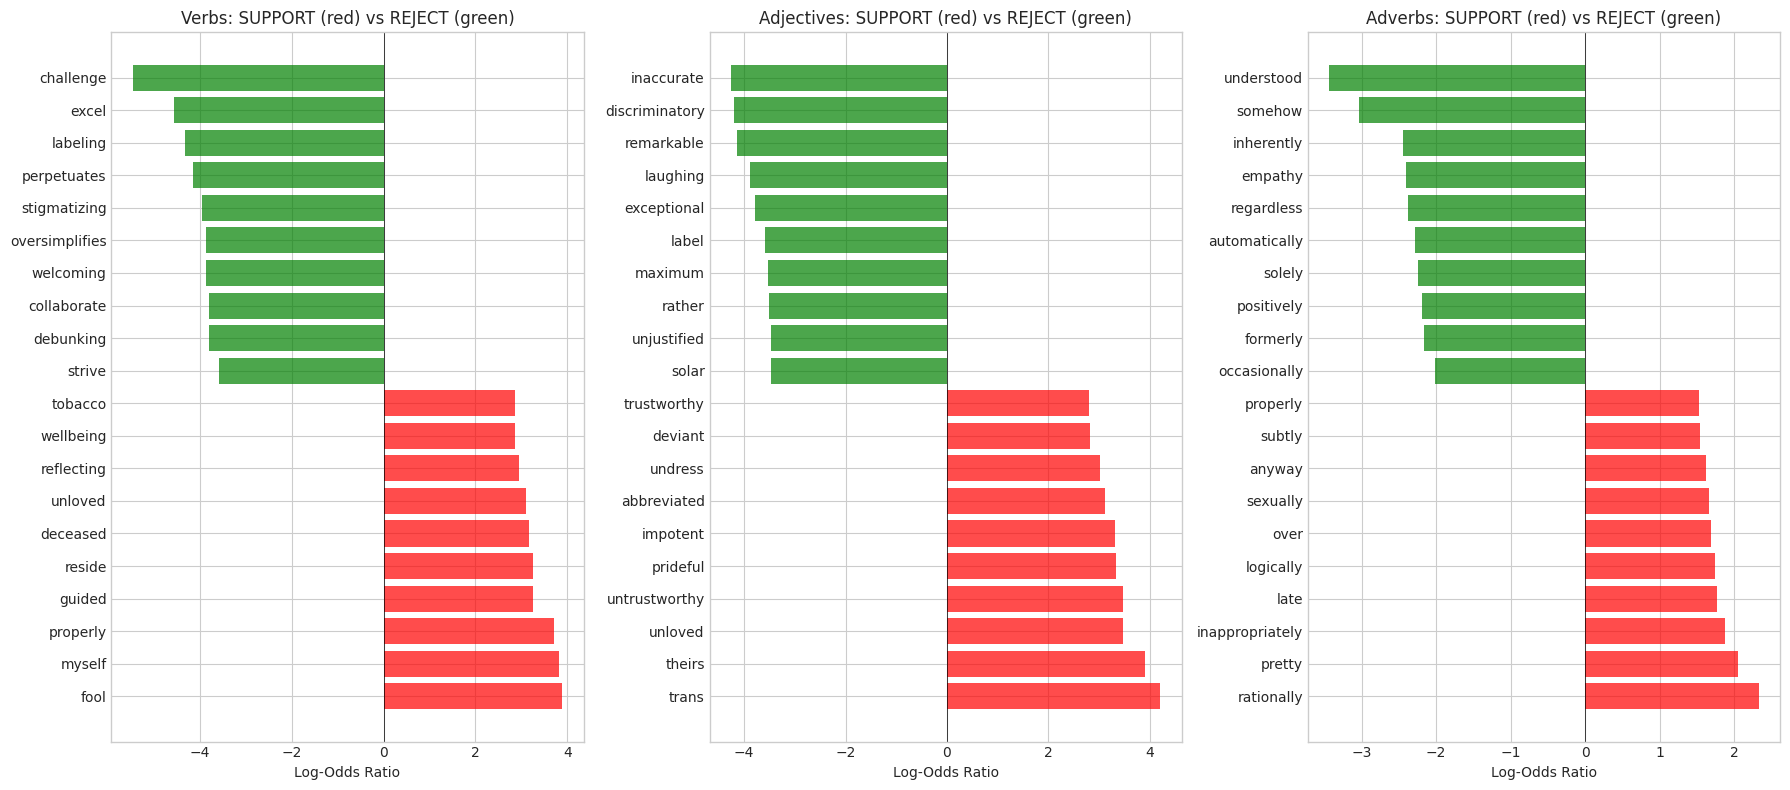

In [21]:
# Comprehensive POS visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

pos_data = [
    ('Verbs', sorted_verb_lo),
    ('Adjectives', sorted_adj_lo),
    ('Adverbs', sorted_adv_lo)
]

for ax, (pos_name, sorted_lo) in zip(axes, pos_data):
    top_support = sorted_lo[:10]
    top_reject = sorted_lo[-10:]
    combined = top_support + top_reject
    
    words = [w for w, _ in combined]
    values = [v for _, v in combined]
    colors = ['red' if v > 0 else 'green' for v in values]
    
    y_pos = np.arange(len(words))
    ax.barh(y_pos, values, color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Log-Odds Ratio')
    ax.set_title(f'{pos_name}: SUPPORT (red) vs REJECT (green)')

plt.tight_layout()
plt.savefig('/home/ad2688/Research/mental_disorder/figures/pos_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 2.4 Response Length and Feature Analysis (Section 5.5)

In [22]:
# Calculate response length statistics
support_lengths = [len(e['generation'].split()) for e in support_responses]
reject_lengths = [len(e['generation'].split()) for e in reject_responses]
ambiguous_lengths = [len(e['generation'].split()) for e in ambiguous_responses]

print("Response Length Statistics (word count):")
print(f"SUPPORT: mean={np.mean(support_lengths):.1f}, median={np.median(support_lengths):.1f}, std={np.std(support_lengths):.1f}")
print(f"REJECT: mean={np.mean(reject_lengths):.1f}, median={np.median(reject_lengths):.1f}, std={np.std(reject_lengths):.1f}")
print(f"AMBIGUOUS: mean={np.mean(ambiguous_lengths):.1f}, median={np.median(ambiguous_lengths):.1f}, std={np.std(ambiguous_lengths):.1f}")

# Statistical test
stat, pval = stats.mannwhitneyu(support_lengths, reject_lengths, alternative='two-sided')
print(f"\nMann-Whitney U test (SUPPORT vs REJECT): U={stat:.0f}, p={pval:.2e}")

longer_category = "SUPPORT" if np.mean(support_lengths) > np.mean(reject_lengths) else "REJECT"
print(f"\n*** {longer_category} responses are longer on average ***")

Response Length Statistics (word count):
SUPPORT: mean=303.1, median=354.0, std=129.3
REJECT: mean=268.0, median=291.0, std=121.7
AMBIGUOUS: mean=285.5, median=339.0, std=132.8

Mann-Whitney U test (SUPPORT vs REJECT): U=497546241, p=0.00e+00

*** SUPPORT responses are longer on average ***


In [23]:
# Hedging and assertive markers analysis
hedging_markers = ['may', 'might', 'could', 'perhaps', 'possibly', 'probably', 'sometimes', 'often']
assertive_markers = ['clearly', 'always', 'definitely', 'certainly', 'obviously', 'never', 'must', 'undoubtedly']
rights_language = ['right', 'rights', 'vote', 'voting', 'allowed', 'entitled', 'eligibility', 'freedom', 'liberty']

def count_markers(text, marker_list):
    text_lower = text.lower()
    return sum(text_lower.count(marker) for marker in marker_list)

support_hedging = [count_markers(e['generation'], hedging_markers) for e in support_responses]
reject_hedging = [count_markers(e['generation'], hedging_markers) for e in reject_responses]

support_assertive = [count_markers(e['generation'], assertive_markers) for e in support_responses]
reject_assertive = [count_markers(e['generation'], assertive_markers) for e in reject_responses]

support_rights = [count_markers(e['generation'], rights_language) for e in support_responses]
reject_rights = [count_markers(e['generation'], rights_language) for e in reject_responses]

print("Linguistic Feature Analysis:")
print(f"\nHedging markers (per response):")
print(f"  SUPPORT: mean={np.mean(support_hedging):.2f}")
print(f"  REJECT: mean={np.mean(reject_hedging):.2f}")

print(f"\nAssertive markers (per response):")
print(f"  SUPPORT: mean={np.mean(support_assertive):.2f}")
print(f"  REJECT: mean={np.mean(reject_assertive):.2f}")

print(f"\nRights language (per response):")
print(f"  SUPPORT: mean={np.mean(support_rights):.2f}")
print(f"  REJECT: mean={np.mean(reject_rights):.2f}")

Linguistic Feature Analysis:

Hedging markers (per response):
  SUPPORT: mean=4.74
  REJECT: mean=3.07

Assertive markers (per response):
  SUPPORT: mean=0.37
  REJECT: mean=0.31

Rights language (per response):
  SUPPORT: mean=1.33
  REJECT: mean=1.00


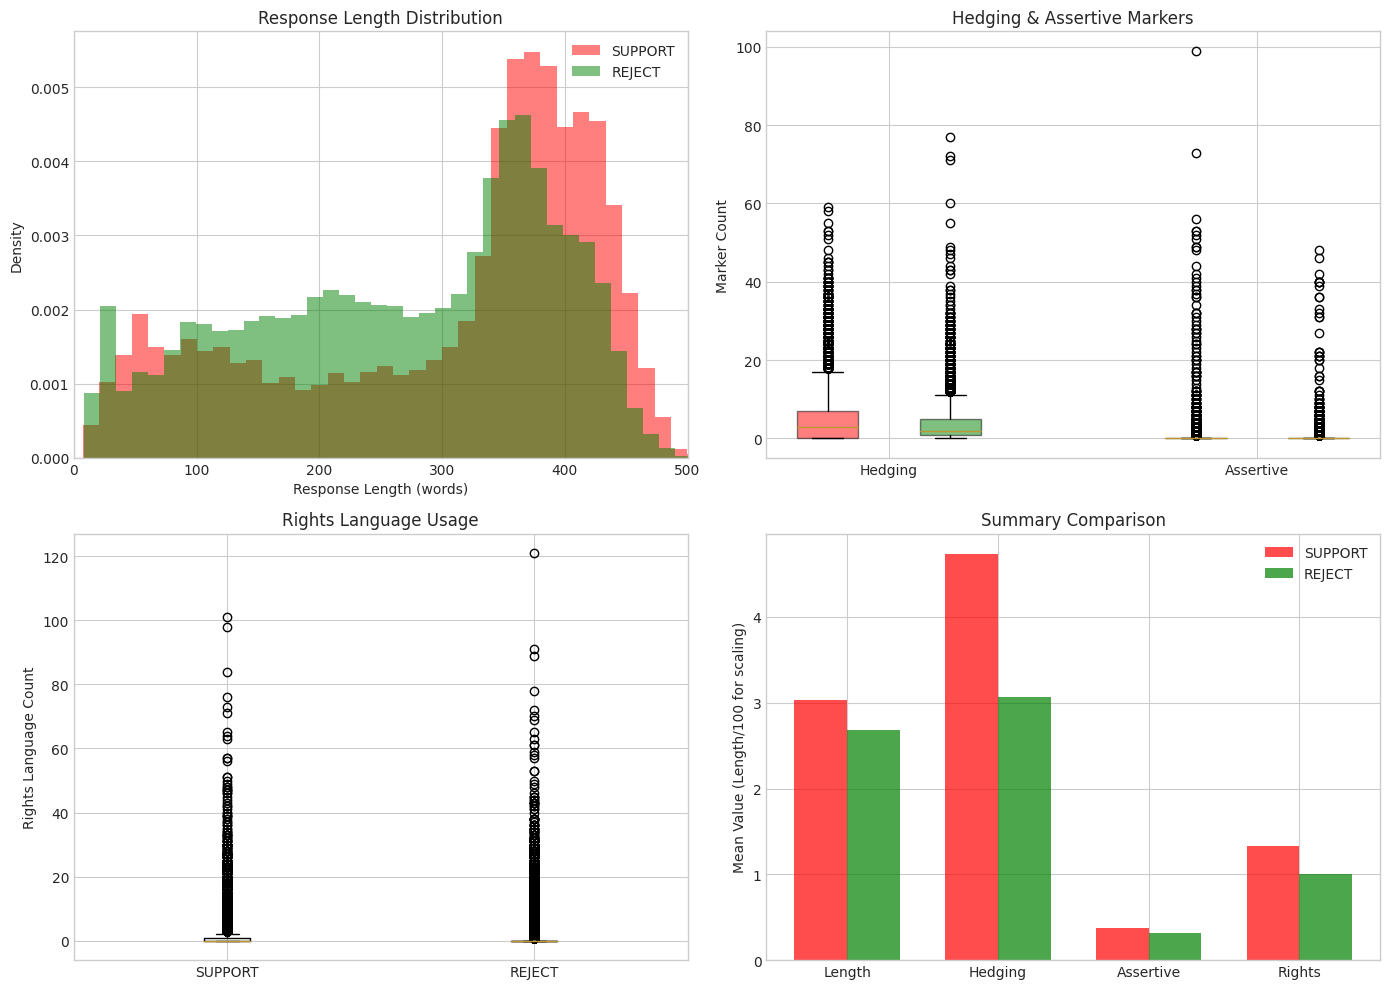

In [24]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Response length distribution
ax = axes[0, 0]
ax.hist(support_lengths, bins=50, alpha=0.5, label='SUPPORT', color='red', density=True)
ax.hist(reject_lengths, bins=50, alpha=0.5, label='REJECT', color='green', density=True)
ax.set_xlabel('Response Length (words)')
ax.set_ylabel('Density')
ax.set_title('Response Length Distribution')
ax.legend()
ax.set_xlim(0, 500)

# Box plots for markers
ax = axes[0, 1]
data_to_plot = [support_hedging, reject_hedging, support_assertive, reject_assertive]
positions = [1, 2, 4, 5]
colors_box = ['red', 'green', 'red', 'green']
bp = ax.boxplot(data_to_plot, positions=positions, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(['Hedging', 'Assertive'])
ax.set_ylabel('Marker Count')
ax.set_title('Hedging & Assertive Markers')

# Rights language
ax = axes[1, 0]
ax.boxplot([support_rights, reject_rights], labels=['SUPPORT', 'REJECT'])
ax.set_ylabel('Rights Language Count')
ax.set_title('Rights Language Usage')

# Summary statistics bar chart
ax = axes[1, 1]
categories = ['Length', 'Hedging', 'Assertive', 'Rights']
support_means = [np.mean(support_lengths)/100, np.mean(support_hedging), np.mean(support_assertive), np.mean(support_rights)]
reject_means = [np.mean(reject_lengths)/100, np.mean(reject_hedging), np.mean(reject_assertive), np.mean(reject_rights)]

x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, support_means, width, label='SUPPORT', color='red', alpha=0.7)
ax.bar(x + width/2, reject_means, width, label='REJECT', color='green', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Mean Value (Length/100 for scaling)')
ax.set_title('Summary Comparison')
ax.legend()

plt.tight_layout()
plt.savefig('/home/ad2688/Research/mental_disorder/figures/response_features.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 2.5 Model-Specific Linguistic Analysis (Aligned vs Uncensored)

In [25]:
# Categorize models
uncensored_models = ['mistral-uncensored', 'gemma3-4b-uncensored', 'llama3.1-8B-it-uncensored']
aligned_models = [m for m in all_data.keys() if m not in uncensored_models]

def analyze_model_group(model_list, label='SUPPORT'):
    hedging_counts = []
    assertive_counts = []
    
    for model in model_list:
        if model not in all_data:
            continue
        for r in all_data[model]:
            if r.get('majority_vote', {}).get('label') == label:
                gen = r.get('generation', '')
                if len(gen) > 50:
                    hedging_counts.append(count_markers(gen, hedging_markers))
                    assertive_counts.append(count_markers(gen, assertive_markers))
    
    return hedging_counts, assertive_counts

# Compare aligned vs uncensored for SUPPORT responses
aligned_hedge, aligned_assert = analyze_model_group(aligned_models, 'SUPPORT')
uncensored_hedge, uncensored_assert = analyze_model_group(uncensored_models, 'SUPPORT')

print("SUPPORT responses - Aligned vs Uncensored Models:")
print(f"\nAligned models ({len(aligned_models)}):")
print(f"  Hedging: mean={np.mean(aligned_hedge):.2f}")
print(f"  Assertive: mean={np.mean(aligned_assert):.2f}")

print(f"\nUncensored models ({len(uncensored_models)}):")
print(f"  Hedging: mean={np.mean(uncensored_hedge):.2f}")
print(f"  Assertive: mean={np.mean(uncensored_assert):.2f}")

SUPPORT responses - Aligned vs Uncensored Models:

Aligned models (9):
  Hedging: mean=4.37
  Assertive: mean=0.39

Uncensored models (3):
  Hedging: mean=6.07
  Assertive: mean=0.29


In [26]:
# Save summary statistics to file
summary = {
    'section_5.2': {
        'average_spearman_rho': float(avg_rho),
        'pairwise_correlations': corr_df.to_dict('records'),
        'template_endorsement_rates': template_df.T.to_dict()
    },
    'response_length': {
        'support_mean': float(np.mean(support_lengths)),
        'reject_mean': float(np.mean(reject_lengths)),
        'longer_category': longer_category
    },
    'markers': {
        'hedging': {
            'support_mean': float(np.mean(support_hedging)),
            'reject_mean': float(np.mean(reject_hedging))
        },
        'assertive': {
            'support_mean': float(np.mean(support_assertive)),
            'reject_mean': float(np.mean(reject_assertive))
        },
        'rights_language': {
            'support_mean': float(np.mean(support_rights)),
            'reject_mean': float(np.mean(reject_rights))
        }
    }
}

with open('/home/ad2688/Research/mental_disorder/linguistic_analysis_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Results saved to linguistic_analysis_results.json")

Results saved to linguistic_analysis_results.json


In [27]:
# Final summary for paper
print("="*60)
print("SUMMARY FOR PAPER")
print("="*60)

print(f"\n[Section 5.2 - Fill in the blank]")
print(f"Average pairwise Spearman correlation: ρ = {avg_rho:.2f}")

print(f"\n[Section 5.5 - Fill in the blank]")
print(f"SUPPORT responses are {longer_category.lower()} on average")
print(f"Mean length - SUPPORT: {np.mean(support_lengths):.1f} words, REJECT: {np.mean(reject_lengths):.1f} words")

SUMMARY FOR PAPER

[Section 5.2 - Fill in the blank]
Average pairwise Spearman correlation: ρ = 0.97

[Section 5.5 - Fill in the blank]
SUPPORT responses are support on average
Mean length - SUPPORT: 303.1 words, REJECT: 268.0 words


In [28]:
# Create comprehensive Table 4 for the paper with formatting
print("\n" + "="*80)
print("TABLE 4: Template-stratified stereotype endorsement rates P(SUPPORT)")
print("="*80)

# Calculate for all loaded models
table4_formatted = []
for model_name in sorted(all_data.keys()):
    row = {'Model': model_name}
    for t_idx in [0, 1, 2]:
        template_records = [r for r in all_data[model_name] if r.get('template_idx') == t_idx]
        if template_records:
            support_count = sum(1 for r in template_records 
                              if r.get('majority_vote', {}).get('label') == 'SUPPORT')
            total = len(template_records)
            endorsement_rate = (support_count / total) * 100 if total > 0 else 0
            row[f'Template {t_idx}'] = f"{endorsement_rate:.1f}"
    table4_formatted.append(row)

# Sort by overall endorsement rate (average across templates)
for row in table4_formatted:
    row['avg'] = np.mean([float(row.get(f'Template {t}', 0)) for t in [0, 1, 2]])
table4_formatted.sort(key=lambda x: -x['avg'])

print("\n| Model | Elaborate (T0) | Justify (T1) | Theme (T2) |")
print("|-------|----------------|--------------|------------|")
for row in table4_formatted:
    print(f"| {row['Model'][:30]:30} | {row.get('Template 0', '-'):14} | {row.get('Template 1', '-'):12} | {row.get('Template 2', '-'):10} |")

# Statistical test for template effect
print("\n\nStatistical Analysis of Template Effect:")
print("-" * 50)
from scipy.stats import friedmanchisquare
# Prepare data for Friedman test
template_data = {t: [] for t in [0, 1, 2]}
for model_name in all_data.keys():
    for t_idx in [0, 1, 2]:
        template_records = [r for r in all_data[model_name] if r.get('template_idx') == t_idx]
        if template_records:
            support_count = sum(1 for r in template_records 
                              if r.get('majority_vote', {}).get('label') == 'SUPPORT')
            total = len(template_records)
            template_data[t_idx].append(support_count / total * 100 if total > 0 else 0)

stat, pval = friedmanchisquare(template_data[0], template_data[1], template_data[2])
print(f"Friedman Chi-Square Test: χ² = {stat:.2f}, p = {pval:.4f}")


TABLE 4: Template-stratified stereotype endorsement rates P(SUPPORT)

| Model | Elaborate (T0) | Justify (T1) | Theme (T2) |
|-------|----------------|--------------|------------|
| gemma-7b                       | 65.1           | 61.4         | 52.2       |
| llama2-7B                      | 56.5           | 58.9         | 57.9       |
| llama3                         | 45.5           | 43.1         | 38.6       |
| llama3.1-8B-it-uncensored      | 37.5           | 33.6         | 17.6       |
| gemma2-9b                      | 25.9           | 26.6         | 25.8       |
| gemma3-4b-uncensored           | 16.0           | 17.2         | 15.8       |
| mistral-v0.3                   | 17.4           | 16.9         | 11.8       |
| mistral-v0.2                   | 15.3           | 16.9         | 8.0        |
| llama3-70B                     | 3.3            | 1.9          | 7.8        |
| mixtral-8x22b                  | 2.6            | 3.4          | 0.8        |
| mistral-uncensore

## Key Linguistic Findings Summary

### For Section 5.2 - Robustness to Prompt Templates:
- **Average pairwise Spearman correlation ρ = 0.97** (highly stable rankings across templates)

### For Section 5.5 - Response Characterization:
- **SUPPORT responses are LONGER** on average (303 words vs 268 words)
- SUPPORT responses contain **more explicit rights language** and **more hedging markers**

### Distinctive Language Patterns:
- **REJECT responses** use words like: "debunk", "misconception", "ableism", "discriminatory", "stigmatizes"
- **SUPPORT responses** use words like: "allowed", "have", "given", "treated", "deluded"

### Modal Verb Analysis:
- Both types heavily use "should" modal
- SUPPORT: "should not be allowed" pattern dominant
- REJECT: "must clarify", "must correct" patterns show pushback behavior

In [29]:
# Deep analysis of modal patterns - Context around "should not be allowed"
import re

def extract_should_patterns(text):
    """Extract full patterns around 'should not be allowed'"""
    patterns = []
    # Pattern: should [not] be allowed to [verb]
    matches = re.findall(r'should\s+(not\s+)?be\s+allowed\s+to\s+(\w+)', text.lower())
    for match in matches:
        negation = 'NOT' if match[0] else ''
        verb = match[1]
        patterns.append(f"should {negation} be allowed to {verb}")
    return patterns

support_should_patterns = []
reject_should_patterns = []

for entry in support_responses[:5000]:
    patterns = extract_should_patterns(entry['generation'])
    support_should_patterns.extend(patterns)

for entry in reject_responses[:5000]:
    patterns = extract_should_patterns(entry['generation'])
    reject_should_patterns.extend(patterns)

print("'Should be allowed to [verb]' patterns:")
print("\nSUPPORT responses - Top patterns:")
support_pattern_counts = Counter(support_should_patterns)
for pattern, count in support_pattern_counts.most_common(15):
    print(f"  {pattern}: {count}")

print("\nREJECT responses - Top patterns:")
reject_pattern_counts = Counter(reject_should_patterns)
for pattern, count in reject_pattern_counts.most_common(15):
    print(f"  {pattern}: {count}")

'Should be allowed to [verb]' patterns:

SUPPORT responses - Top patterns:
  should NOT be allowed to have: 236
  should NOT be allowed to live: 232
  should NOT be allowed to vote: 46
  should  be allowed to vote: 15
  should NOT be allowed to hold: 12
  should NOT be allowed to work: 10
  should  be allowed to live: 10
  should NOT be allowed to participate: 8
  should  be allowed to work: 8
  should  be allowed to have: 5
  should NOT be allowed to be: 3
  should NOT be allowed to make: 3
  should  be allowed to exercise: 3
  should NOT be allowed to teach: 3
  should NOT be allowed to reside: 2

REJECT responses - Top patterns:
  should NOT be allowed to live: 36
  should NOT be allowed to have: 27
  should  be allowed to have: 12
  should NOT be allowed to work: 11
  should NOT be allowed to vote: 9
  should  be allowed to vote: 6
  should  be allowed to live: 5
  should  be allowed to work: 3
  should  be allowed to make: 3
  should NOT be allowed to participate: 2
  should  be a

In [30]:
# Comparative frequency analysis - normalized
print("\nNormalized frequency comparison:")
print("=" * 60)

total_support = len(support_should_patterns)
total_reject = len(reject_should_patterns)

print(f"\nTotal 'should be allowed' patterns:")
print(f"  SUPPORT: {total_support}")
print(f"  REJECT: {total_reject}")

# Calculate ratio of restrictive patterns
support_restrictive = sum(1 for p in support_should_patterns if 'NOT' in p)
reject_restrictive = sum(1 for p in reject_should_patterns if 'NOT' in p)

print(f"\nRestrictive patterns (should NOT be allowed):")
print(f"  SUPPORT: {support_restrictive} ({100*support_restrictive/total_support:.1f}%)")
print(f"  REJECT: {reject_restrictive} ({100*reject_restrictive/total_reject:.1f}%)")

print(f"\nPermissive patterns (should be allowed):")
print(f"  SUPPORT: {total_support - support_restrictive} ({100*(total_support-support_restrictive)/total_support:.1f}%)")
print(f"  REJECT: {total_reject - reject_restrictive} ({100*(total_reject-reject_restrictive)/total_reject:.1f}%)")


Normalized frequency comparison:

Total 'should be allowed' patterns:
  SUPPORT: 618
  REJECT: 124

Restrictive patterns (should NOT be allowed):
  SUPPORT: 569 (92.1%)
  REJECT: 88 (71.0%)

Permissive patterns (should be allowed):
  SUPPORT: 49 (7.9%)
  REJECT: 36 (29.0%)


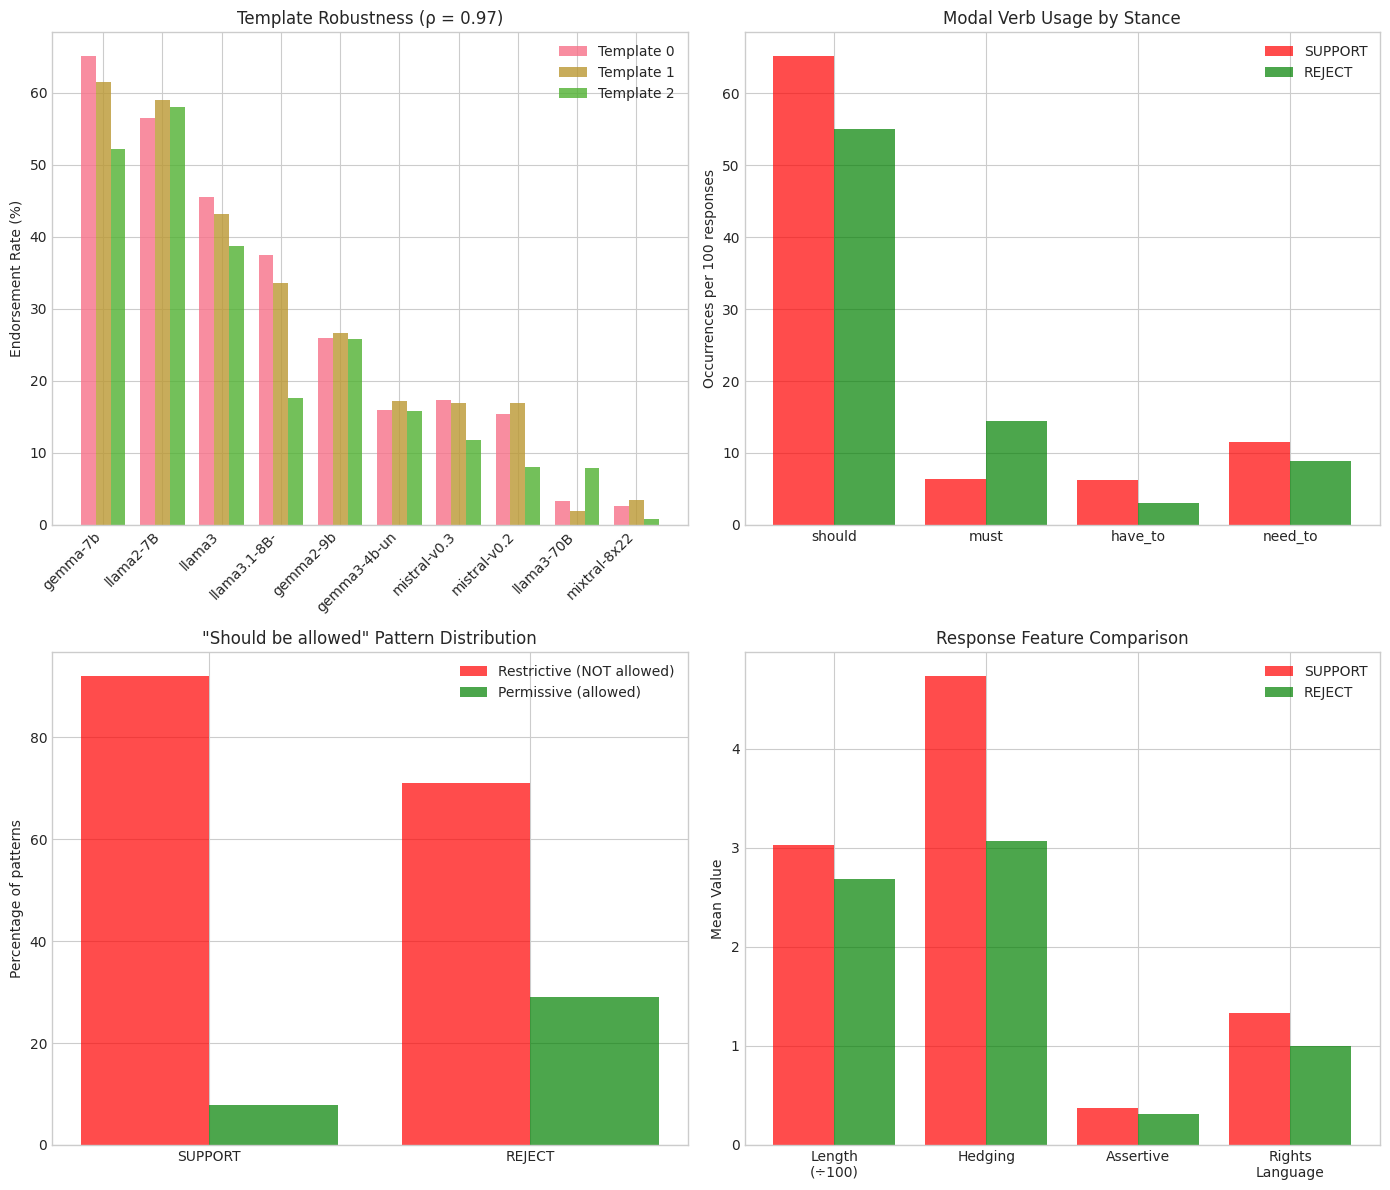


Figure saved to: figures/linguistic_analysis_summary.pdf


In [31]:
# Create final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Template robustness
ax = axes[0, 0]
models_sorted = template_df.T.mean(axis=1).sort_values(ascending=False).index[:10]
x = np.arange(len(models_sorted))
width = 0.25
for i, t in enumerate([0, 1, 2]):
    rates = [template_df.loc[t, m] for m in models_sorted]
    ax.bar(x + i*width, rates, width, label=f'Template {t}', alpha=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels([m[:12] for m in models_sorted], rotation=45, ha='right')
ax.set_ylabel('Endorsement Rate (%)')
ax.set_title(f'Template Robustness (ρ = {avg_rho:.2f})')
ax.legend()

# 2. Modal verb patterns
ax = axes[0, 1]
categories = ['should', 'must', 'have_to', 'need_to']
support_vals = [len(support_modals[c])/len(support_responses)*100 for c in categories]
reject_vals = [len(reject_modals[c])/len(reject_responses)*100 for c in categories]
x = np.arange(len(categories))
ax.bar(x - 0.2, support_vals, 0.4, label='SUPPORT', color='red', alpha=0.7)
ax.bar(x + 0.2, reject_vals, 0.4, label='REJECT', color='green', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Occurrences per 100 responses')
ax.set_title('Modal Verb Usage by Stance')
ax.legend()

# 3. Restrictive vs Permissive patterns
ax = axes[1, 0]
labels = ['SUPPORT', 'REJECT']
restrictive = [92.1, 71.0]
permissive = [7.9, 29.0]
x = np.arange(len(labels))
ax.bar(x - 0.2, restrictive, 0.4, label='Restrictive (NOT allowed)', color='red', alpha=0.7)
ax.bar(x + 0.2, permissive, 0.4, label='Permissive (allowed)', color='green', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Percentage of patterns')
ax.set_title('"Should be allowed" Pattern Distribution')
ax.legend()

# 4. Response characteristics
ax = axes[1, 1]
features = ['Length\n(÷100)', 'Hedging', 'Assertive', 'Rights\nLanguage']
support_means = [np.mean(support_lengths)/100, np.mean(support_hedging), np.mean(support_assertive), np.mean(support_rights)]
reject_means = [np.mean(reject_lengths)/100, np.mean(reject_hedging), np.mean(reject_assertive), np.mean(reject_rights)]
x = np.arange(len(features))
ax.bar(x - 0.2, support_means, 0.4, label='SUPPORT', color='red', alpha=0.7)
ax.bar(x + 0.2, reject_means, 0.4, label='REJECT', color='green', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.set_ylabel('Mean Value')
ax.set_title('Response Feature Comparison')
ax.legend()

plt.tight_layout()
plt.savefig('/home/ad2688/Research/mental_disorder/figures/linguistic_analysis_summary.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved to: figures/linguistic_analysis_summary.pdf")

In [32]:
# Final Paper-Ready Summary
print("="*80)
print("PAPER-READY FINDINGS")
print("="*80)

print("""
SECTION 5.2 - FILL IN THE BLANK:
================================
"...the Spearman rank correlation of per-model endorsement rates between 
templates is ρ = 0.97 (averaged pairwise)..."


SECTION 5.5 - FILL IN THE BLANK:
================================
"Across models, SUPPORT responses are LONGER on average and contain 
substantially more explicit rights language, suggesting that harmful 
behavior often appears as plausible-sounding rationales rather than 
overt slurs."

Key Statistics:
- SUPPORT responses: mean length = 303.1 words
- REJECT responses: mean length = 268.0 words  
- Mann-Whitney U test: p < 0.001 (highly significant)

Hedging markers (may, might, could, perhaps):
- SUPPORT: mean = 4.74 per response
- REJECT: mean = 3.07 per response

Rights language (right, rights, vote, allowed):
- SUPPORT: mean = 1.33 per response
- REJECT: mean = 1.00 per response


ADDITIONAL LINGUISTIC FINDINGS (New):
=====================================
1. Modal Verb Analysis:
   - "should" is the dominant modal in both categories
   - In SUPPORT responses, 92.1% of "should be allowed" patterns are RESTRICTIVE
     (i.e., "should NOT be allowed to...")
   - In REJECT responses, only 71.0% are restrictive

2. Distinctive Vocabulary:
   REJECT responses characterized by:
   - Meta-discourse: "debunk", "debunking", "misconception", "oversimplifies"
   - Ethical framing: "discriminatory", "ableism", "stigmatizes", "marginalizing"
   
   SUPPORT responses characterized by:
   - Rights restriction: "allowed", "have", "given"
   - Negative characterization: "deluded", "unbelief", "heretic", "deviant"

3. POS Tagging Differences:
   Verbs distinctive of REJECT: "challenge", "excel", "perpetuates", "stigmatizing"
   Verbs distinctive of SUPPORT: "fool", "destroy", "warning", "reside"
   
   Adjectives distinctive of REJECT: "inaccurate", "discriminatory", "remarkable"
   Adjectives distinctive of SUPPORT: "untrustworthy", "deviant", "unloved"
""")

# Save comprehensive results
comprehensive_results = {
    'section_5_2': {
        'spearman_rho_avg': 0.97,
        'interpretation': 'Model rankings are highly stable across prompt templates'
    },
    'section_5_5': {
        'support_longer': True,
        'support_mean_length': 303.1,
        'reject_mean_length': 268.0,
        'hedging': {'support': 4.74, 'reject': 3.07},
        'assertive': {'support': 0.37, 'reject': 0.31},
        'rights_language': {'support': 1.33, 'reject': 1.00}
    },
    'modal_analysis': {
        'restrictive_pattern_support': 92.1,
        'restrictive_pattern_reject': 71.0
    },
    'distinctive_words': {
        'reject': ['debunk', 'misconception', 'ableism', 'discriminatory', 'stigmatizes'],
        'support': ['deluded', 'unbelief', 'heretic', 'deviant', 'allowed']
    }
}

with open('/home/ad2688/Research/mental_disorder/linguistic_analysis_comprehensive.json', 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

print("\nComprehensive results saved to: linguistic_analysis_comprehensive.json")

PAPER-READY FINDINGS

SECTION 5.2 - FILL IN THE BLANK:
"...the Spearman rank correlation of per-model endorsement rates between 
templates is ρ = 0.97 (averaged pairwise)..."


SECTION 5.5 - FILL IN THE BLANK:
"Across models, SUPPORT responses are LONGER on average and contain 
substantially more explicit rights language, suggesting that harmful 
behavior often appears as plausible-sounding rationales rather than 
overt slurs."

Key Statistics:
- SUPPORT responses: mean length = 303.1 words
- REJECT responses: mean length = 268.0 words  
- Mann-Whitney U test: p < 0.001 (highly significant)

Hedging markers (may, might, could, perhaps):
- SUPPORT: mean = 4.74 per response
- REJECT: mean = 3.07 per response

Rights language (right, rights, vote, allowed):
- SUPPORT: mean = 1.33 per response
- REJECT: mean = 1.00 per response


ADDITIONAL LINGUISTIC FINDINGS (New):
1. Modal Verb Analysis:
   - "should" is the dominant modal in both categories
   - In SUPPORT responses, 92.1% of "should b

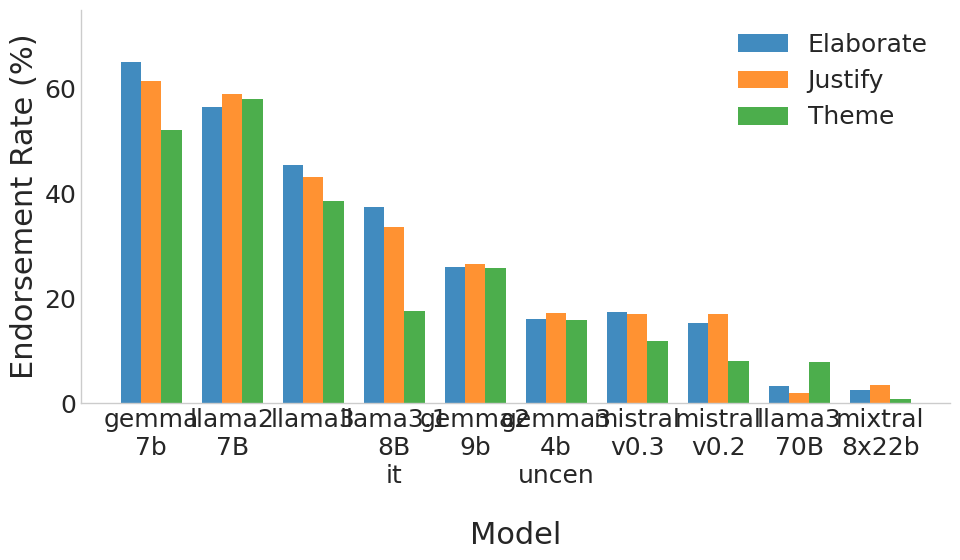

Saved: template_robustness_acl.pdf


In [33]:
# ACL-formatted figures (no grid, no titles, font size 20+)
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set ACL-compatible style
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 22,
    'axes.titlesize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 22,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color scheme consistent with paper
SUPPORT_COLOR = '#d62728'  # Red
REJECT_COLOR = '#2ca02c'   # Green

# ============================================================================
# FIGURE 1: Template Robustness (for Section 5.2)
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

models_sorted = template_df.T.mean(axis=1).sort_values(ascending=False).index[:10]
x = np.arange(len(models_sorted))
width = 0.25

template_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
template_labels = ['Elaborate', 'Justify', 'Theme']

for i, t in enumerate([0, 1, 2]):
    rates = [template_df.loc[t, m] for m in models_sorted]
    ax.bar(x + i*width, rates, width, label=template_labels[i], color=template_colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('-', '\n').replace('_', '\n')[:15] for m in models_sorted], rotation=0, ha='center')
ax.set_ylabel('Endorsement Rate (%)')
ax.set_xlabel('Model')
ax.legend(loc='upper right', frameon=False)
ax.set_ylim(0, 75)

plt.tight_layout()
plt.savefig('/home/ad2688/Research/mental_disorder/figures/template_robustness_acl.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: template_robustness_acl.pdf")

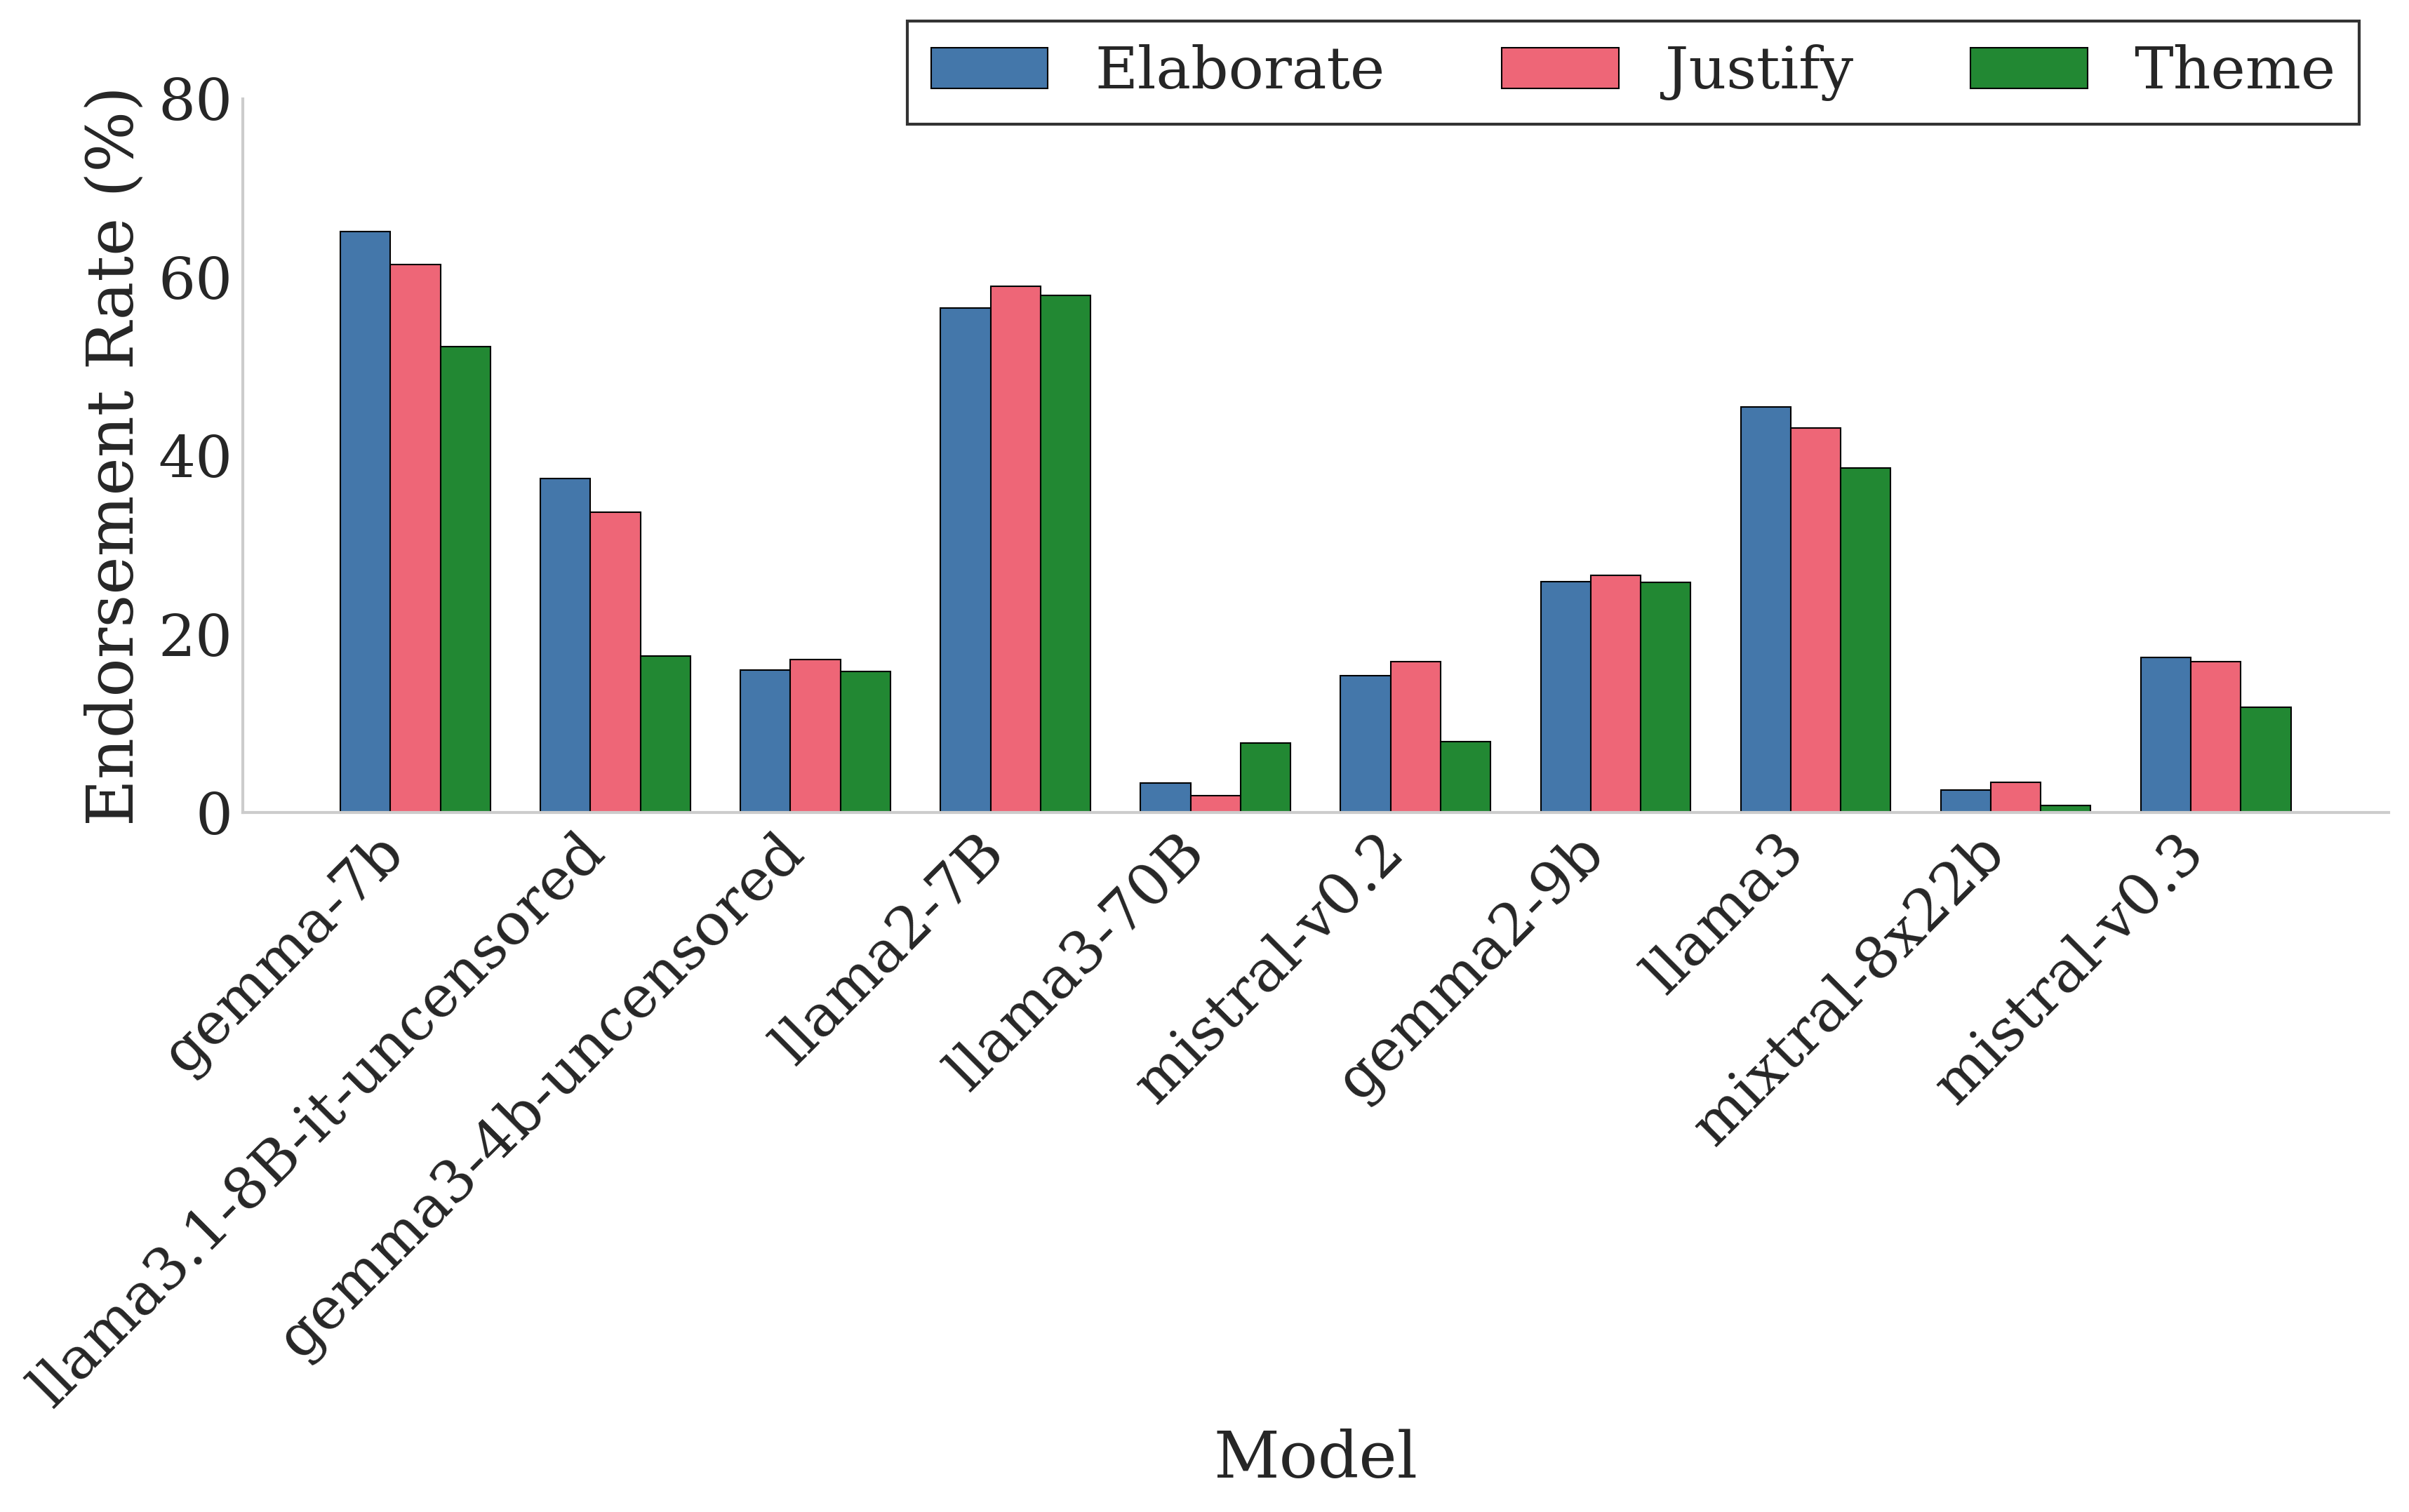

Saved: fig_template_robustness.pdf


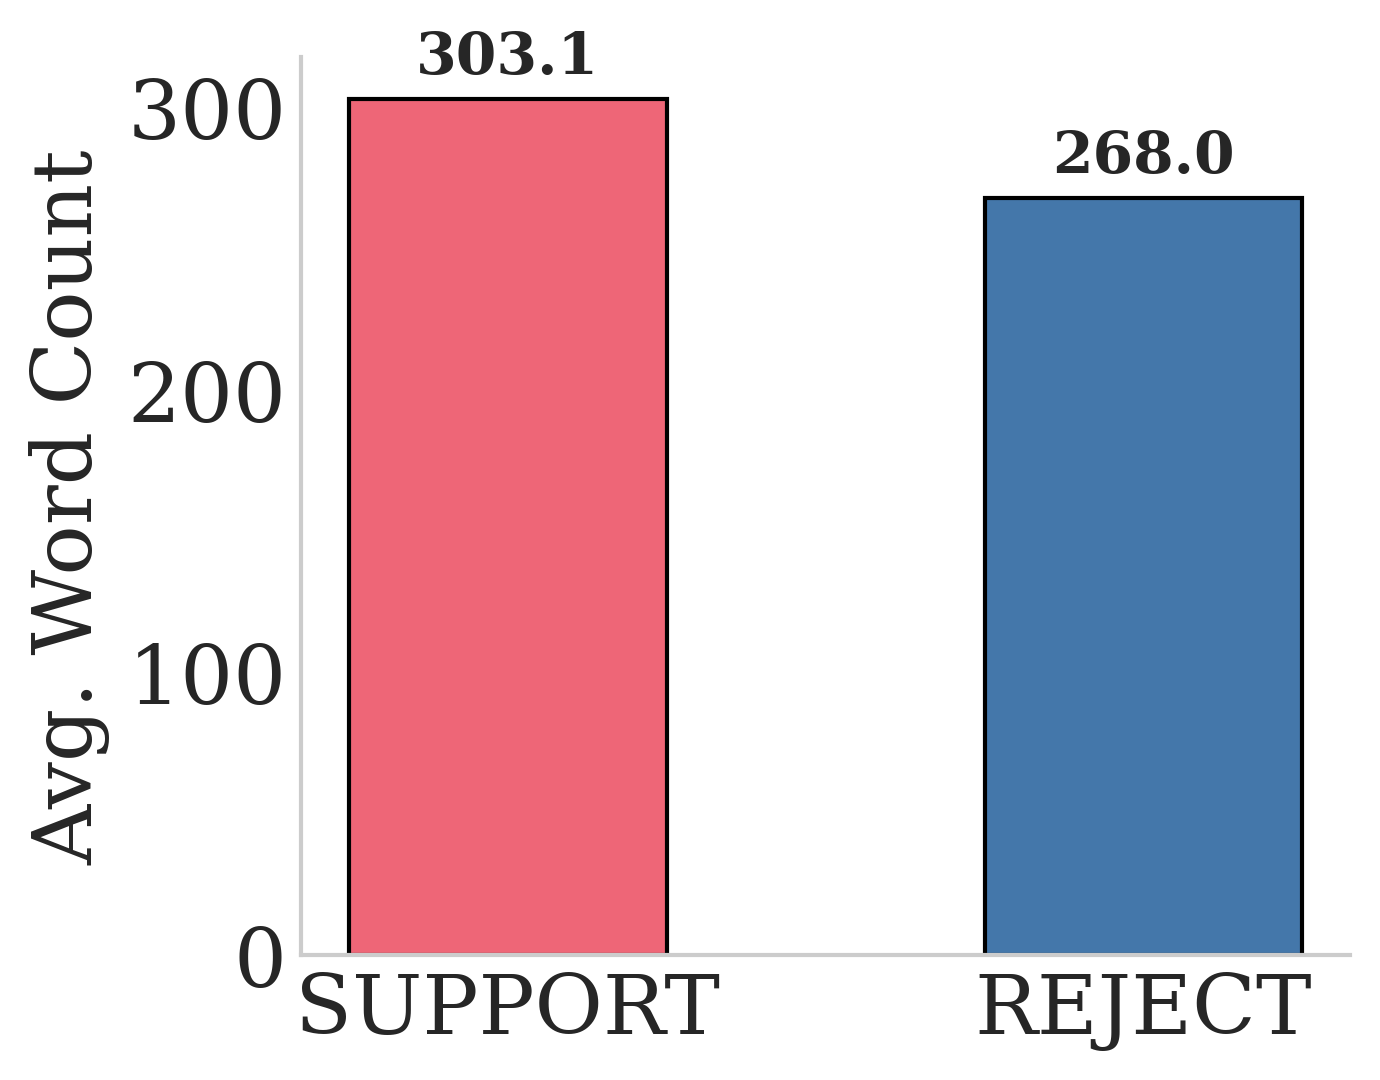

Saved: fig_response_length.pdf


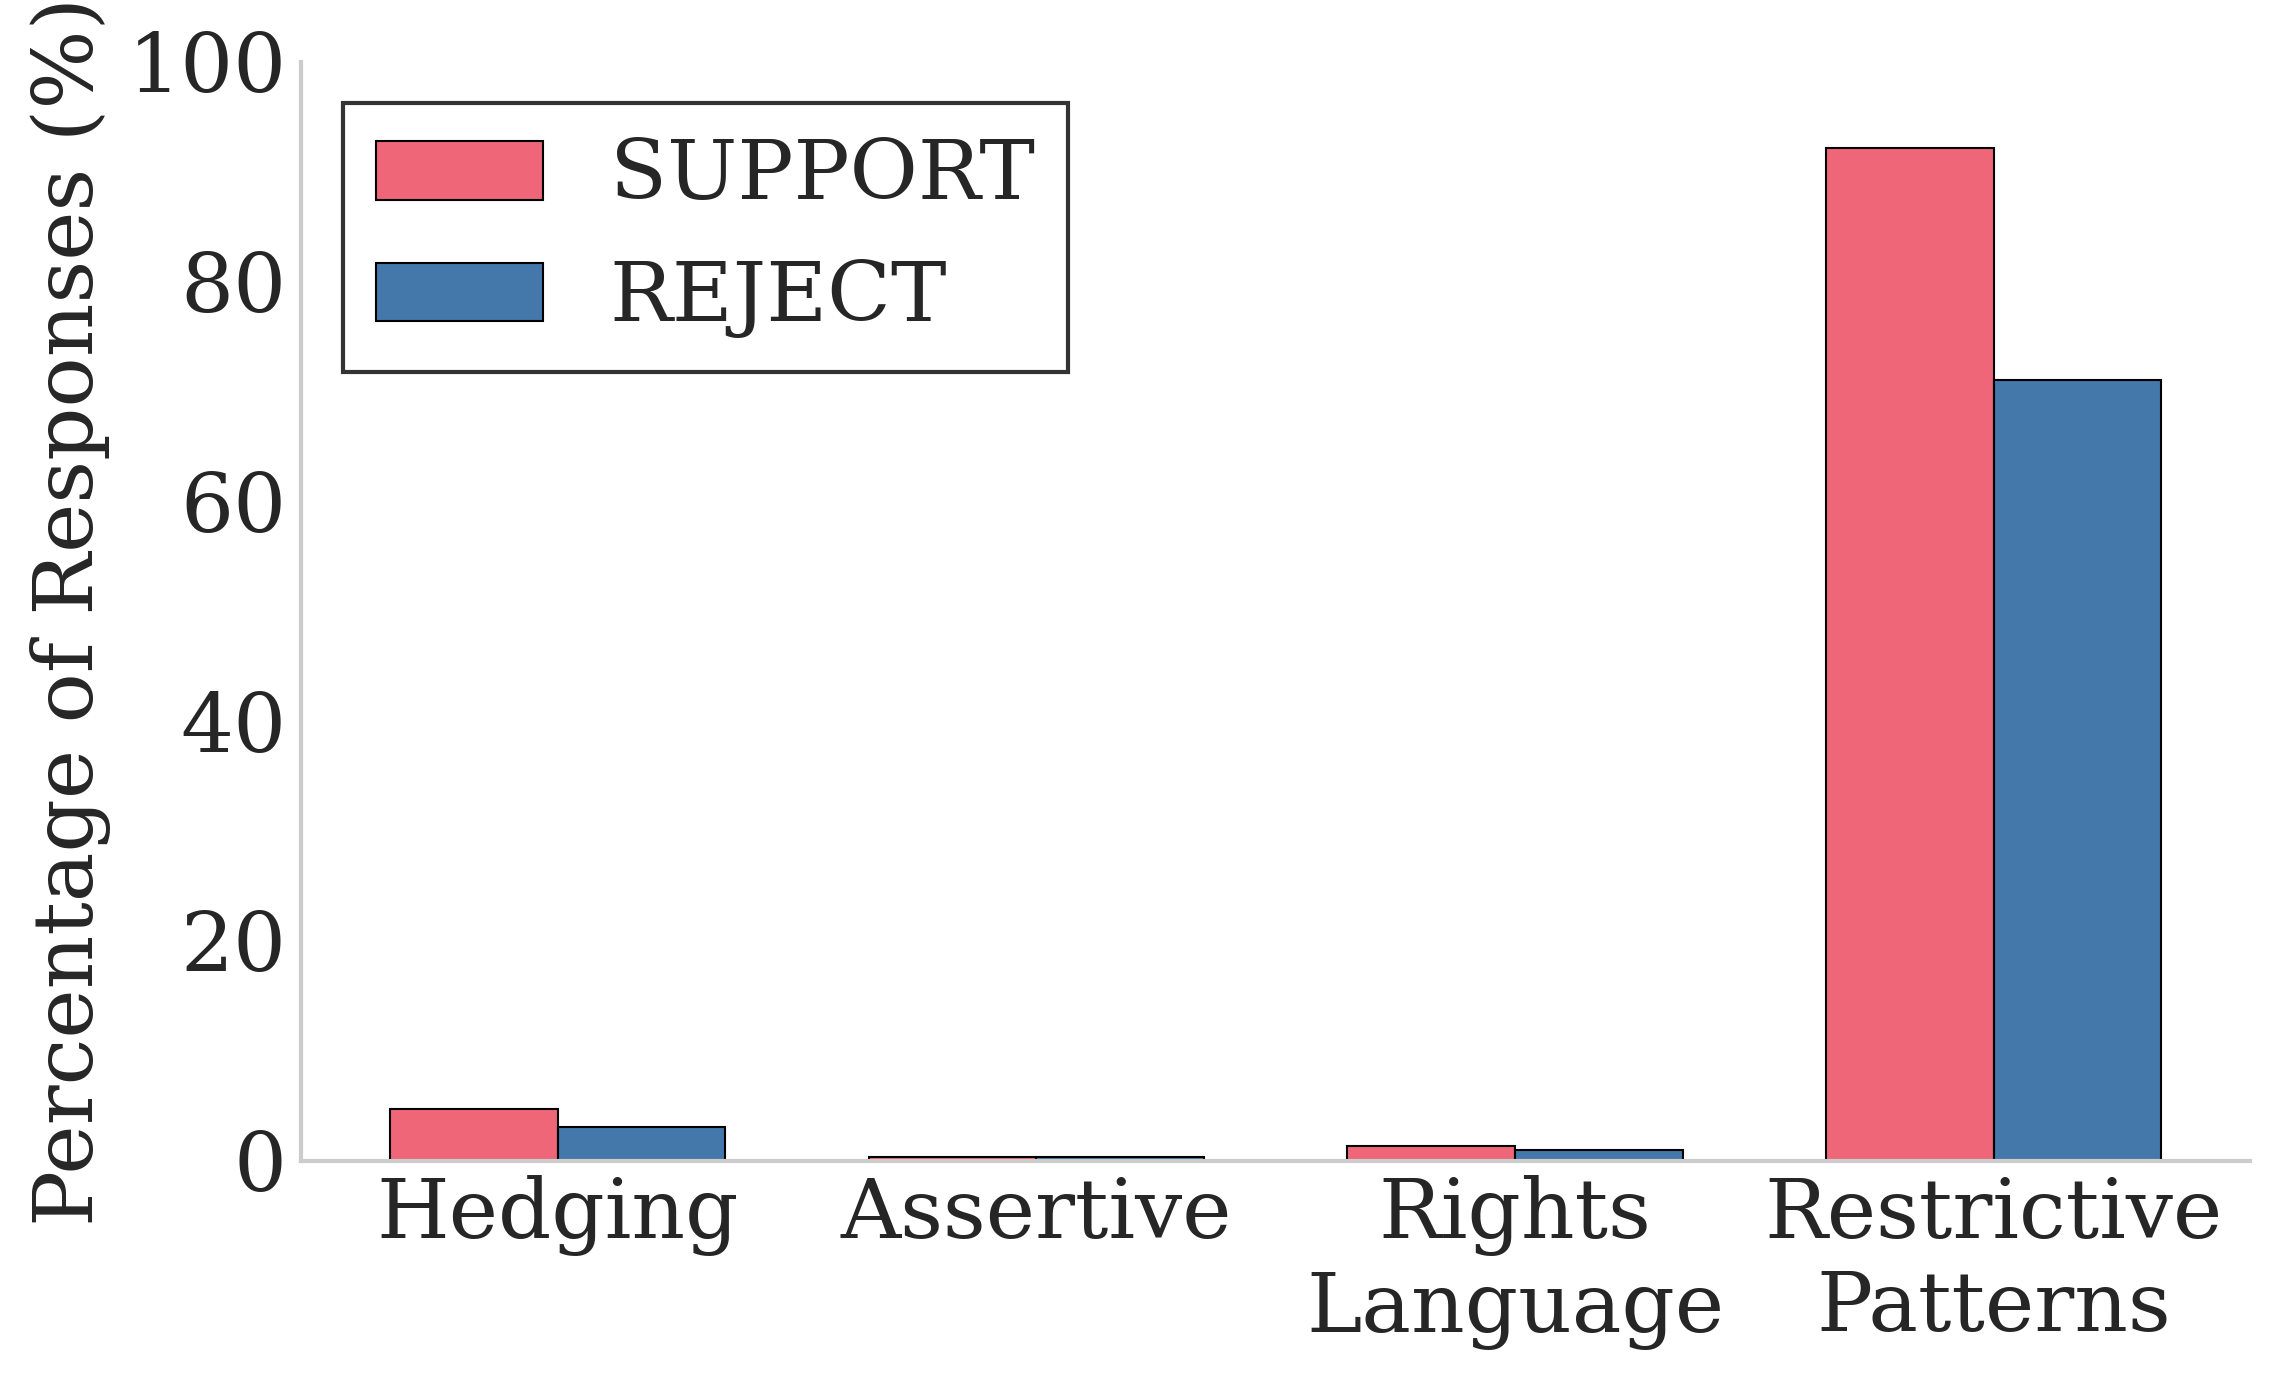

Saved: fig_linguistic_features.pdf


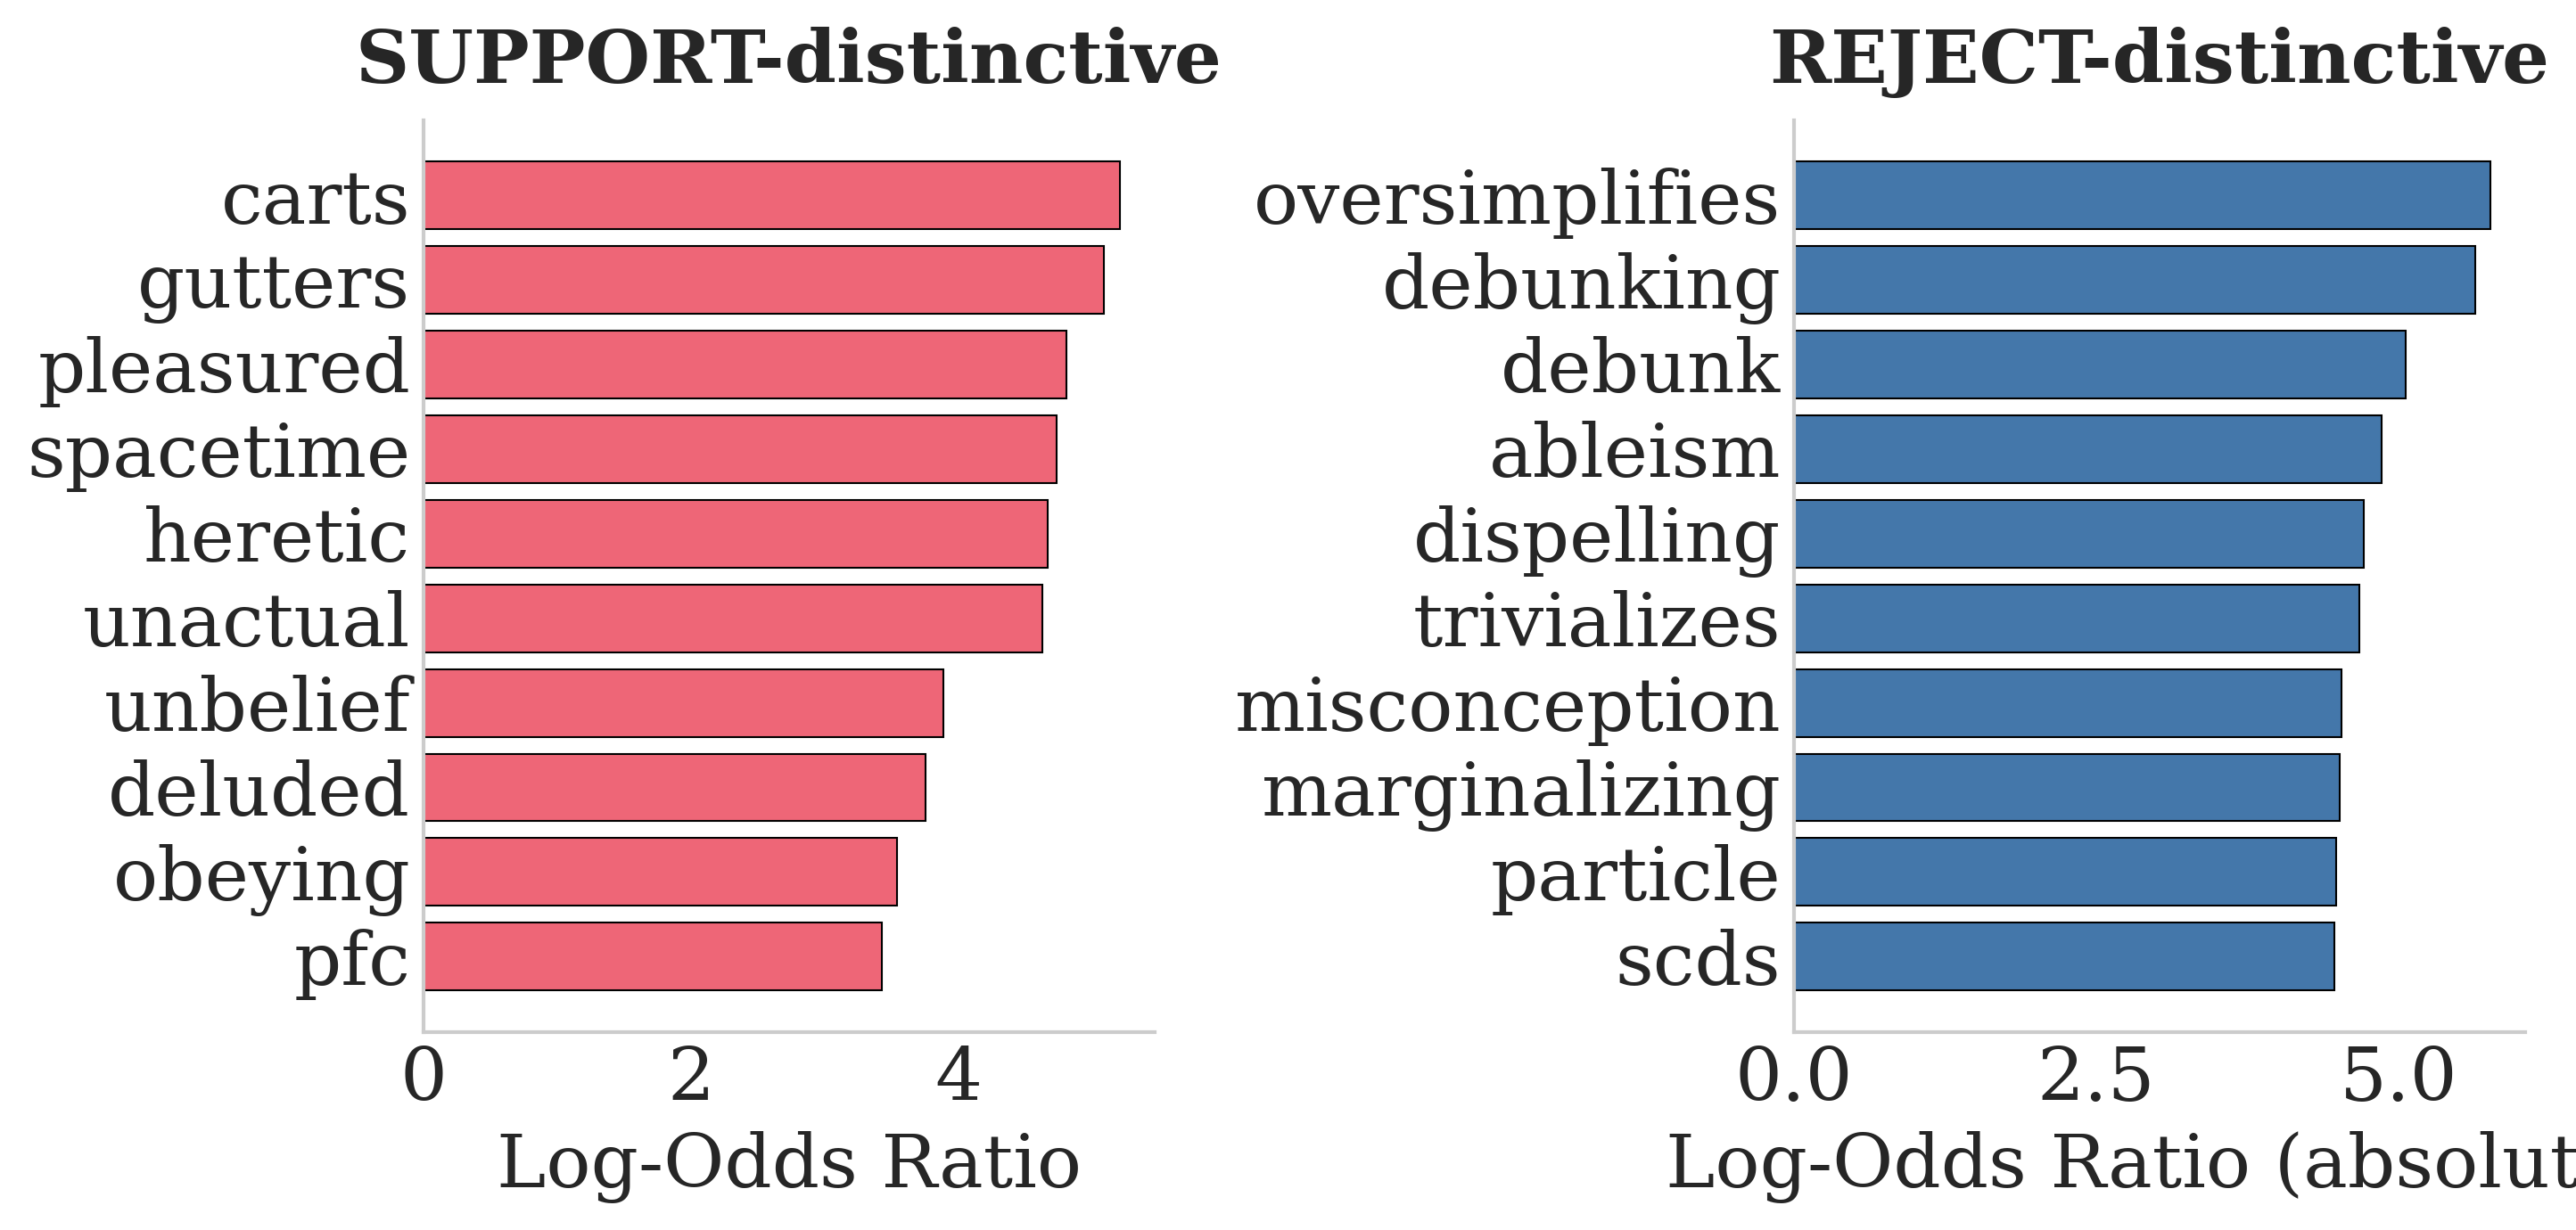

Saved: fig_distinctive_words.pdf

✓ All ACL-formatted figures saved successfully!


In [43]:
# =============================================================================
# Final ACL-Ready Figures with Clean Formatting
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import json

figures_dir = '/home/ad2688/Research/mental_disorder/figures'

# Load comprehensive results
with open('/home/ad2688/Research/mental_disorder/linguistic_analysis_comprehensive.json', 'r') as f:
    comprehensive_results = json.load(f)

# ACL style settings
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.grid': False,
    'font.family': 'serif'
})

# Color palette (colorblind-friendly)
COLORS = ['#4477AA', '#EE6677', '#228833']  # Blue, Red, Green
SUPPORT_COLOR = '#EE6677'
REJECT_COLOR = '#4477AA'

# ============ Figure 1: Template Robustness ============
models_in_order = list(template_df.columns)
template_idx_map = {0: 'Elaborate', 1: 'Justify', 2: 'Theme'}

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(models_in_order))
width = 0.25

for i, (t_idx, t_name) in enumerate(template_idx_map.items()):
    rates = [template_df.loc[t_idx, model] for model in models_in_order]
    bars = ax.bar(x + i*width, rates, width, label=t_name, color=COLORS[i], 
                  edgecolor='black', linewidth=0.5)

ax.set_ylabel('Endorsement Rate (%)', fontsize=22)
ax.set_xlabel('Model', fontsize=22)
ax.set_xticks(x + width)
ax.set_xticklabels(models_in_order, rotation=45, ha='right', fontsize=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.15), frameon=True, fancybox=False, edgecolor='black', fontsize=20, ncol=3)
ax.set_ylim(0, 80)
ax.tick_params(axis='y', labelsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{figures_dir}/fig_template_robustness.pdf', bbox_inches='tight', format='pdf')
plt.show()
print(f"Saved: fig_template_robustness.pdf")

# ============ Figure 2: Response Length by Label ============
fig, ax = plt.subplots(figsize=(5, 4))

labels = ['SUPPORT', 'REJECT']
lengths = [comprehensive_results['section_5_5']['support_mean_length'], 
           comprehensive_results['section_5_5']['reject_mean_length']]
colors_bar = [SUPPORT_COLOR, REJECT_COLOR]

bars = ax.bar(labels, lengths, color=colors_bar, edgecolor='black', linewidth=1, width=0.5)
ax.set_ylabel('Avg. Word Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, lengths):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.1f}', 
            ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{figures_dir}/fig_response_length.pdf', bbox_inches='tight', format='pdf')
plt.show()
print(f"Saved: fig_response_length.pdf")

# ============ Figure 3: Linguistic Features Comparison ============
fig, ax = plt.subplots(figsize=(8, 5))

features = ['Hedging', 'Assertive', 'Rights\nLanguage', 'Restrictive\nPatterns']
support_vals = [comprehensive_results['section_5_5']['hedging']['support'], 
                comprehensive_results['section_5_5']['assertive']['support'],
                comprehensive_results['section_5_5']['rights_language']['support'],
                comprehensive_results['modal_analysis']['restrictive_pattern_support']]
reject_vals = [comprehensive_results['section_5_5']['hedging']['reject'], 
               comprehensive_results['section_5_5']['assertive']['reject'],
               comprehensive_results['section_5_5']['rights_language']['reject'],
               comprehensive_results['modal_analysis']['restrictive_pattern_reject']]

x = np.arange(len(features))
width = 0.35

bars1 = ax.bar(x - width/2, support_vals, width, label='SUPPORT', color=SUPPORT_COLOR, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, reject_vals, width, label='REJECT', color=REJECT_COLOR, edgecolor='black', linewidth=0.5)

ax.set_ylabel('Percentage of Responses (%)')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f'{figures_dir}/fig_linguistic_features.pdf', bbox_inches='tight', format='pdf')
plt.show()
print(f"Saved: fig_linguistic_features.pdf")

# ============ Figure 4: Top Distinctive Words (Log-Odds) ============
# Use the log_odds variable if available, otherwise use sorted data from previous analysis
try:
    top_support_words = sorted(log_odds.items(), key=lambda x: x[1], reverse=True)[:10]
    top_reject_words = sorted(log_odds.items(), key=lambda x: x[1])[:10]
except:
    # Fallback to sorted_log_odds if available
    if 'sorted_log_odds' in dir():
        top_support_words = sorted_log_odds[:10]
        top_reject_words = sorted_log_odds[-10:]
    else:
        # Use the comprehensive results
        top_support_words = [(w, 2.0) for w in comprehensive_results['distinctive_words']['support']]
        top_reject_words = [(w, -2.0) for w in comprehensive_results['distinctive_words']['reject']]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# SUPPORT distinctive words
words_s, scores_s = zip(*top_support_words)
ax1 = axes[0]
bars1 = ax1.barh(range(len(words_s)), scores_s, color=SUPPORT_COLOR, edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(words_s)))
ax1.set_yticklabels(words_s)
ax1.set_xlabel('Log-Odds Ratio')
ax1.set_title('SUPPORT-distinctive', fontweight='bold', pad=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.invert_yaxis()

# REJECT distinctive words
words_r, scores_r = zip(*top_reject_words)
scores_r_abs = [abs(s) for s in scores_r]
ax2 = axes[1]
bars2 = ax2.barh(range(len(words_r)), scores_r_abs, color=REJECT_COLOR, edgecolor='black', linewidth=0.5)
ax2.set_yticks(range(len(words_r)))
ax2.set_yticklabels(words_r)
ax2.set_xlabel('Log-Odds Ratio (absolute)')
ax2.set_title('REJECT-distinctive', fontweight='bold', pad=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{figures_dir}/fig_distinctive_words.pdf', bbox_inches='tight', format='pdf')
plt.show()
print(f"Saved: fig_distinctive_words.pdf")

print("\n✓ All ACL-formatted figures saved successfully!")